# 🏥 CDC Mortality Risk Prediction

**Dataset:** CDC BRFSS 2023 (LLCP2023.XPT)  
**Goal:** Predict whether a person is HIGH or LOW mortality risk  
**Type:** Binary Classification  
---

##  Step 1 — Problem Understanding

### What are we solving?
We build a **binary classifier** to identify individuals at **HIGH MORTALITY RISK**  
using the CDC BRFSS 2023 health survey — the largest health telephone survey in the world.

### Why is this useful?
Doctors cannot call 433,000 patients one by one. A machine learning model can  
**automatically flag high-risk individuals** so healthcare workers focus their  
attention where it matters most.

### What is binary classification?
We predict one of two outcomes for each person:
- `1` = **HIGH RISK** — has at least one serious life-threatening condition
- `0` = **LOW RISK**  — no major life-threatening conditions reported

### How do we define HIGH RISK?
Our dataset has no "death" column — it surveys living people.  
So we **engineer** the target variable using clinical knowledge.

A person is **HIGH RISK = 1** if they have ANY of:

| Condition | Why it matters |
|-----------|----------------|
| Heart Attack | #1 cause of death in the US |
| Heart Disease | Direct cardiovascular mortality |
| Stroke | #5 cause of death |
| Diabetes | Damages kidneys, heart, nerves — accelerates all conditions |
| Kidney Disease | Organ failure, requires dialysis |
| COPD | Progressive irreversible lung destruction |
| Cancer (non-skin) | Direct mortality cause |
| Poor General Health (score=5) | Self-rated health is one of strongest mortality predictors |

Otherwise **LOW RISK = 0**.

> **Note on Depression:** Depression was considered but removed from the target.  
> It is an indirect risk factor, not a direct mortality cause.  
> We keep it as a **feature** (predictor) instead.

---
##  Step 1B — Project Justification

---

###  Problem Statement
The CDC BRFSS surveys 433,000+ living Americans every year but records **no mortality outcome**.
We must identify **HIGH RISK** individuals using only self-reported health and behavioral data —
no blood tests, no lab values required — so healthcare workers can intervene early.

---

###  Complexity Involved

| Complexity Layer | Description |
|-----------------|-------------|
| No direct target | `high_risk` must be engineered from 8 clinical conditions — not given directly |
| Large dataset | 433,323 rows × 350 columns — requires domain-guided column selection |
| Hidden codes | 7/77/9/99/88 mask real missing values — must decode before analysis |
| Implied decimal | BMI stored as 2573 meaning 25.73 — invisible without domain knowledge |
| 7-strategy imputation | Different strategy per column — not a blanket fill |
| Data leakage trap | condition_count built from target columns → phantom 98.88% accuracy |
| Class imbalance | 35%/65% split — must assess SMOTE (not needed at 1:1.9) |
| Non-linear patterns | BMI U-curve, sick-quitter bias — LR alone cannot capture these |

---

###  Commercial Value
- Healthcare providers can flag HIGH RISK patients **before** they present with advanced illness
- Reduces emergency intervention costs through early preventive care
- Insurance companies can use survey-based risk scoring without expensive lab tests
- Every 1% Recall improvement = ~4,330 additional HIGH RISK individuals correctly identified

---

###  Academic Value
- Proves self-reported survey data alone carries sufficient signal for mortality risk prediction
- Documents the data leakage lesson rigorously: 98.88% (leaked) → 75.49% (honest)
- Validates classic public health findings (Hispanic Paradox, sick-quitter bias, BMI paradox)
  in a 433K ML context, confirming domain knowledge improves model design
- Reproducible open-data pipeline on CDC's publicly available BRFSS dataset

---

###  Social Value
- Quantifies the **2.6× income-based risk gap** — evidence for targeting underserved populations
- Deployable for populations with no access to clinical testing (rural, uninsured)
- Enables outreach-driven identification before crisis presentation in low-income communities
- Findings directly inform CDC budget decisions for chronic disease prevention programs

---
##  Step 2 — Load Dataset

###  Step 2A — Import Libraries

**What we are doing:**  
Importing all Python libraries needed for the entire project in one place.

**Why import everything upfront?**  
Industry convention — anyone reading your notebook immediately sees  
every tool used. No surprises mid-notebook.

| Library | Purpose |
|---------|---------|
| `pandas` | Loading, cleaning, manipulating data (our main workhorse) |
| `numpy` | Numerical operations, NaN handling |
| `matplotlib` | Base plotting library |
| `seaborn` | Statistical charts built on top of matplotlib |
| `sklearn` | Machine learning — imputers, models, metrics |
| `warnings` | Suppress non-critical warning messages |

In [1]:
# ── Import Libraries ──────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
)

# Global plot style
sns.set_style('darkgrid')
plt.rcParams.update({
    'figure.dpi'      : 120,
    'font.size'       : 11,
    'axes.titlesize'  : 13,
    'axes.titleweight': 'bold',
})

COLORS = {
    'high_risk' : '#C0392B',
    'low_risk'  : '#1A7A4A',
    'primary'   : '#1B3A6B',
    'secondary' : '#0D7377',
    'highlight' : '#E08B00',
    'palette'   : ['#1B3A6B','#0D7377','#C0392B','#E08B00','#1A7A4A','#2E86AB']
}

print('Libraries imported successfully!')

Libraries imported successfully!


###  Step 2B — Load Dataset

**What we are doing:**  
Loading the raw CDC BRFSS `.XPT` (SAS transport format) file into a pandas DataFrame.

**Why `.XPT` format?**  
The CDC publishes BRFSS data in SAS format because government agencies  
historically use SAS for statistical analysis. We use `pd.read_sas()` to read it.

**What `encoding='latin-1'` means:**  
The file uses an older character encoding from the 1980s.  
Without this argument Python throws an encoding error on special characters.

In [2]:
# ── Load Dataset 

FILE_PATH = '/Users/omnaik/Desktop/PROJECTS/CDC_Mortality_Risk/data/LLCP2023.XPT '

print('Loading dataset... this may take 1-3 minutes...')
df = pd.read_sas(FILE_PATH, encoding='latin-1')

print(f'Dataset loaded successfully!')
print(f'  Rows    : {df.shape[0]:,}')
print(f'  Columns : {df.shape[1]:,}')
print(f'  Memory  : {df.memory_usage(deep=True).sum()/1e6:.0f} MB')

Loading dataset... this may take 1-3 minutes...
Dataset loaded successfully!
  Rows    : 433,323
  Columns : 350
  Memory  : 1331 MB


###  Step 2C — Select & Rename Columns

**What we are doing:**  
Selecting only 35 out of 350 columns we need, then renaming them  
from cryptic BRFSS codes to clear, readable English names.

**Why rename columns?**  
Column names like `CVDINFR4` and `_INCOMG1` are SAS legacy codes.  
They are impossible to read at a glance. Renaming to `heart_attack`  
and `income` makes every line of code self-explanatory.

**Why only 35 columns?**  
350 columns = ~1,330 MB memory. Selecting 35 = ~124 MB.  
A 10x reduction that makes everything run faster.  
This is called **reducing the dataset footprint** — standard industry practice.

**Column categories we selected:**

| Category | Count | What they capture |
|----------|-------|-------------------|
| Target components | 8 | Conditions that define HIGH RISK |
| Demographics | 8 | Age, sex, race, income, education |
| Chronic conditions | 5 | BP, cholesterol, asthma, arthritis, depression |
| Health behaviors | 5 | BMI, smoking, exercise, drinking |
| Health status days | 3 | Physical/mental bad days per month |
| Healthcare access | 4 | Insurance, doctor visits, cost barriers |
| Geography | 2 | Urban vs rural, metro vs non-metro |

In [3]:
# ── Select & Rename Columns

COLUMN_MAP = {
    # Target components
    'CVDINFR4'  : 'heart_attack',
    'CVDCRHD4'  : 'heart_disease',
    'CVDSTRK3'  : 'stroke',
    'DIABETE4'  : 'diabetes',
    'CHCKDNY2'  : 'kidney_disease',
    'CHCCOPD3'  : 'copd',
    'CHCOCNC1'  : 'cancer',
    'GENHLTH'   : 'general_health',
    # Demographics
    '_AGE_G'    : 'age_group',
    '_AGE80'    : 'age',
    '_SEX'      : 'sex',
    '_RACE'     : 'race',
    '_EDUCAG'   : 'education',
    '_INCOMG1'  : 'income',
    'MARITAL'   : 'marital_status',
    'EMPLOY1'   : 'employment',
    # Chronic conditions
    'BPHIGH6'   : 'high_bp',
    'TOLDHI3'   : 'high_cholesterol',
    'ASTHMA3'   : 'asthma',
    'HAVARTH4'  : 'arthritis',
    'ADDEPEV3'  : 'depression',
    # Health behaviors
    '_BMI5'     : 'bmi',
    '_BMI5CAT'  : 'bmi_category',
    '_SMOKER3'  : 'smoking_status',
    '_PACAT3'   : 'physical_activity',
    '_RFBING6'  : 'binge_drinking',
    # Health status days
    'PHYSHLTH'  : 'physical_health_days',
    'MENTHLTH'  : 'mental_health_days',
    'POORHLTH'  : 'poor_health_days',
    # Healthcare access
    'MEDCOST1'  : 'cost_barrier',
    'CHECKUP1'  : 'last_checkup',
    'PERSDOC3'  : 'has_doctor',
    '_HLTHPL1'  : 'has_insurance',
    # Geography
    '_METSTAT'  : 'metro_status',
    '_URBSTAT'  : 'urban_status',
}

df_raw = df.copy()
df     = df[list(COLUMN_MAP.keys())].copy()
df     = df.rename(columns=COLUMN_MAP)

print(f'Memory before : {df_raw.memory_usage(deep=True).sum()/1e6:.0f} MB')
print(f'Memory after  : {df.memory_usage(deep=True).sum()/1e6:.0f} MB')
print(f'Shape         : {df.shape}')
print(f'\nColumns renamed successfully!')

Memory before : 1331 MB
Memory after  : 121 MB
Shape         : (433323, 35)

Columns renamed successfully!


---
##  Data Dictionary

**Dataset:** CDC Behavioral Risk Factor Surveillance System (BRFSS) 2023  
**Source:** https://www.cdc.gov/brfss  
**Rows:** 433,323 respondents  
**Columns selected:** 35 out of 350  

>  **BRFSS Special Codes:**  
> `7 / 77` = Don't know &nbsp;|&nbsp; `9 / 99` = Refused &nbsp;|&nbsp; `88` = None (zero days) &nbsp;|&nbsp; `Blank` = Not asked

---

###  Target Components — used to BUILD high_risk label

| Column | Original | Description | Values |
|--------|----------|-------------|--------|
| `heart_attack` | CVDINFR4 | Ever told you had a heart attack | 1=Yes, 2=No |
| `heart_disease` | CVDCRHD4 | Ever told you had coronary heart disease | 1=Yes, 2=No |
| `stroke` | CVDSTRK3 | Ever told you had a stroke | 1=Yes, 2=No |
| `diabetes` | DIABETE4 | Ever told you have diabetes | 1=Yes, 2=Pregnancy, 3=No, 4=Borderline |
| `kidney_disease` | CHCKDNY2 | Ever told you have kidney disease | 1=Yes, 2=No |
| `copd` | CHCCOPD3 | Ever told you have COPD | 1=Yes, 2=No |
| `cancer` | CHCOCNC1 | Ever told you have non-skin cancer | 1=Yes, 2=No |
| `general_health` | GENHLTH | Self-reported health status | 1=Excellent → 5=Poor |

---

###  Demographic Features

| Column | Original | Description | Values |
|--------|----------|-------------|--------|
| `age_group` | _AGE_G | Age group category | 1=18-24, 2=25-34, 3=35-44, 4=45-54, 5=55-64, 6=65+ |
| `age` | _AGE80 | Continuous age (top-coded at 80) | 18–80 |
| `sex` | _SEX | Sex of respondent | 1=Male, 2=Female |
| `race` | _RACE | Race and ethnicity | 1=White, 2=Black, 3=AI/AN, 4=Asian, 5=PI, 6=Other, 7=Multi, 8=Hispanic |
| `education` | _EDUCAG | Highest education level | 1=No HS, 2=HS grad, 3=Some college, 4=College grad |
| `income` | _INCOMG1 | Annual household income | 1=<$15K, 2=$15-25K, 3=$25-35K, 4=$35-50K, 5=$50-100K, 6=$100-200K, 7=$200K+ |
| `marital_status` | MARITAL | Marital status | 1=Married, 2=Divorced, 3=Widowed, 4=Separated, 5=Never married |
| `employment` | EMPLOY1 | Employment status | 1=Employed, 2=Self-employed, 3=Out of work, 4=Homemaker, 5=Student, 6=Retired, 7=Unable to work |

---

###  Chronic Condition Features

| Column | Original | Description | Values |
|--------|----------|-------------|--------|
| `high_bp` | BPHIGH6 | Ever told you have high blood pressure | 1=Yes, 2=Pregnancy, 3=No, 4=Borderline |
| `high_cholesterol` | TOLDHI3 | Ever told you have high cholesterol | 1=Yes, 2=No |
| `asthma` | ASTHMA3 | Ever told you have asthma | 1=Yes, 2=No |
| `arthritis` | HAVARTH4 | Ever told you have arthritis | 1=Yes, 2=No |
| `depression` | ADDEPEV3 | Ever told you have depression | 1=Yes, 2=No |

---

###  Health Behavior Features

| Column | Original | Description | Values |
|--------|----------|-------------|--------|
| `bmi` | _BMI5 | Computed BMI (stored as implied decimal) | 2573 = 25.73 |
| `bmi_category` | _BMI5CAT | BMI category | 1=Underweight, 2=Normal, 3=Overweight, 4=Obese |
| `smoking_status` | _SMOKER3 | Computed smoking status | 1=Daily, 2=Some days, 3=Former, 4=Never |
| `physical_activity` | _PACAT3 | Physical activity level | 1=Highly active, 2=Active, 3=Insufficiently active, 4=Inactive |
| `binge_drinking` | _RFBING6 | Binge drinking past 30 days | 1=No, 2=Yes |

---

###  Health Status Features

| Column | Original | Description | Values |
|--------|----------|-------------|--------|
| `physical_health_days` | PHYSHLTH | Days physical health NOT good (past 30) | 0–30, 88=None |
| `mental_health_days` | MENTHLTH | Days mental health NOT good (past 30) | 0–30, 88=None |
| `poor_health_days` | POORHLTH | Days poor health limited activities (past 30) | 0–30, 88=None |

---

###  Healthcare Access Features

| Column | Original | Description | Values |
|--------|----------|-------------|--------|
| `cost_barrier` | MEDCOST1 | Could not see doctor due to cost | 1=Yes, 2=No |
| `last_checkup` | CHECKUP1 | Time since last routine checkup | 1=Within 1yr, 2=1-2yrs, 3=2-5yrs, 4=5+ yrs, 8=Never |
| `has_doctor` | PERSDOC3 | Has a personal doctor | 1=Yes one, 2=Yes more, 3=No |
| `has_insurance` | _HLTHPL1 | Has any health care coverage | 1=Yes, 2=No |

---

###  Geography Features

| Column | Original | Description | Values |
|--------|----------|-------------|--------|
| `metro_status` | _METSTAT | Metropolitan status | 1=Metropolitan, 2=Non-metropolitan |
| `urban_status` | _URBSTAT | Urban or rural | 1=Urban, 2=Rural |

---
##  Step 3 — Data Cleaning

Raw BRFSS data has several issues we must fix before any analysis:

| Problem | What it looks like | Fix |
|---------|--------------------|-----|
| Fake codes hiding missing values | `7.0`, `9.0`, `77.0`, `99.0` in data | Replace with `NaN` |
| Zero days coded as 88 | `88.0` in health day columns | Replace with `0` |
| BMI stored without decimal | `2573` instead of `25.73` | Divide by 100 |
| Duplicate rows | Same person appears twice | Remove duplicates |
| Binary columns coded 1/2 instead of 1/0 | `2` means No | Recode 2 → 0 |
| Missing values (after revealing above) | `NaN` throughout dataset | Logical imputation |

###  Step 3A — Replace BRFSS Special Codes with NaN

**What we are doing:**  
Replacing BRFSS non-answer codes with proper `NaN` (Python's missing value marker).

**Why this is critical:**  
When someone does not know their answer or refuses to answer,  
BRFSS records a special code number instead of leaving the field blank:
- `7` or `77` = "Don't know"
- `9` or `99` = "Refused to answer"

**The problem if we skip this step:**  
Imagine the column `heart_attack` — valid values are 1=Yes, 2=No.  
If someone refused, BRFSS records `9`. Without replacing it, our model  
thinks `9` is a valid category meaning something — it learns completely  
wrong patterns from these fake numbers.

**Why missing values INCREASE after this step:**  
This is correct and expected. We are not creating new missing values —  
we are revealing the missing values that were hiding behind fake numbers.  
Think of it like removing a disguise — the truth was always there.

```
Before: heart_attack = [1.0, 2.0, 9.0, 7.0, 1.0]
                                     ↑     ↑
                               Refused  Don't know

After:  heart_attack = [1.0, 2.0, NaN, NaN, 1.0]
                                     ↑     ↑
                               Now correctly marked as missing
```

In [4]:
# ── Step 3A: Replace BRFSS special codes with NaN 

print(f'Missing values BEFORE : {df.isnull().sum().sum():,}')

special_codes = {
    'heart_attack'        : [7, 9],    'heart_disease'       : [7, 9],
    'stroke'              : [7, 9],    'diabetes'            : [7, 9],
    'kidney_disease'      : [7, 9],    'copd'                : [7, 9],
    'cancer'              : [7, 9],    'general_health'      : [7, 9],
    'sex'                 : [7, 9],    'race'                : [7, 9],
    'education'           : [9],       'income'              : [9],
    'marital_status'      : [9],       'employment'          : [9],
    'age_group'           : [14],
    'high_bp'             : [7, 9],    'high_cholesterol'    : [7, 9],
    'asthma'              : [7, 9],    'arthritis'           : [7, 9],
    'depression'          : [7, 9],
    'smoking_status'      : [9],       'physical_activity'   : [9],
    'binge_drinking'      : [9],       'bmi_category'        : [9],
    'cost_barrier'        : [7, 9],    'last_checkup'        : [7, 9],
    'has_doctor'          : [7, 9],    'has_insurance'       : [9],
    'physical_health_days': [77, 99],  'mental_health_days'  : [77, 99],
    'poor_health_days'    : [77, 99],
}

for col, codes in special_codes.items():
    df[col] = df[col].replace(codes, np.nan)

print(f'Missing values AFTER  : {df.isnull().sum().sum():,}')
print(f'Increase is expected — we revealed truth hiding behind codes 7, 9, 77, 99')

Missing values BEFORE : 333,796
Missing values AFTER  : 676,412
Increase is expected — we revealed truth hiding behind codes 7, 9, 77, 99


###  Step 3B — Fix Health Days Columns (88 = Zero Days)

**What we are doing:**  
Replacing `88` with `0` in three columns: `physical_health_days`,  
`mental_health_days`, and `poor_health_days`.

**Why BRFSS uses 88 instead of 0:**  
In older SAS survey systems, `0` was often reserved for "not asked" or "skip".  
So BRFSS used `88` as a special code meaning "none — zero bad days".

**The problem without this fix:**  
The valid range for these columns is 0 to 30 (days in a month).  
If we leave `88` in the data, the model thinks this person had 88 bad days  
in a month — which is physically impossible and completely corrupts the model.

```
Before: physical_health_days = [88.0, 5.0, 88.0, 20.0]
                                  ↑             ↑
                             Means 0       Means 0  — but stored as 88

After:  physical_health_days = [0.0,  5.0,  0.0,  20.0]
                                  ↑             ↑
                             Now correct        Now correct
```

In [5]:
# ── Step 3B: Fix health days columns 

health_cols = ['physical_health_days', 'mental_health_days', 'poor_health_days']

for col in health_cols:
    df[col] = df[col].replace(88, 0)

print('Health days fixed: 88 replaced with 0')
for col in health_cols:
    print(f'  {col:<25} range: {df[col].min():.0f} - {df[col].max():.0f}')

Health days fixed: 88 replaced with 0
  physical_health_days      range: 0 - 30
  mental_health_days        range: 0 - 30
  poor_health_days          range: 0 - 30


###  Step 3C — Fix BMI Column (Implied Decimal)

**What we are doing:**  
Dividing the `bmi` column by 100 to convert it from BRFSS's stored format  
to the real decimal BMI value.

**Why BRFSS stores BMI this way:**  
The SAS format used by BRFSS cannot easily store decimal numbers  
in fixed-width fields. So they store BMI multiplied by 100 as an integer.

**How it works:**
```
Stored value  →  Real BMI  →  Category
   1823       →   18.23    →  Underweight
   2573       →   25.73    →  Overweight  
   3142       →   31.42    →  Obese
```

**Without this fix:**  
The model thinks someone has a BMI of 2,573. Since all values are 1,800–5,000,  
the entire BMI column becomes meaningless noise.

**Unrealistic values:**  
After dividing, any BMI below 10 or above 100 is biologically impossible —  
these are data errors that we replace with `NaN`.

In [6]:
# ── Step 3C: Fix BMI column 

print(f'BMI sample BEFORE : {df["bmi"].dropna().head(3).tolist()}')

df['bmi'] = df['bmi'] / 100

df.loc[(df['bmi'] < 10) | (df['bmi'] > 100), 'bmi'] = np.nan

print(f'BMI sample AFTER  : {[round(x,2) for x in df["bmi"].dropna().head(3).tolist()]}')
print(f'BMI valid range   : {df["bmi"].min():.1f} - {df["bmi"].max():.1f}')

BMI sample BEFORE : [3047.0, 2856.0, 2231.0]
BMI sample AFTER  : [30.47, 28.56, 22.31]
BMI valid range   : 12.0 - 99.8


###  Step 3D — Remove Duplicate Rows

**What we are doing:**  
Checking for and removing any rows that appear more than once.

**Why duplicates are dangerous in ML:**  
If a duplicate row appears in both the training set and the test set,  
the model has already "seen" that exact person — it is essentially cheating.  
This inflates accuracy scores and gives a false sense of good performance.

**Why duplicates exist in BRFSS:**  
Government survey data is collected across many states and merged centrally.  
When batches are merged, occasional duplicates slip through.  
We always check — even in clean government datasets.

**`reset_index(drop=True)`:**  
After removing rows, the index has gaps (e.g. 0, 1, 4, 5... — row 2 and 3 gone).  
This resets the index back to a clean 0, 1, 2, 3... sequence.

In [7]:
# ── Step 3D: Remove duplicates

before = len(df)
df     = df.drop_duplicates().reset_index(drop=True)
after  = len(df)

print(f'Rows before : {before:,}')
print(f'Rows after  : {after:,}')
print(f'Removed     : {before - after:,} duplicates ({(before-after)/before*100:.3f}%)')

Rows before : 433,323
Rows after  : 433,051
Removed     : 272 duplicates (0.063%)


###  Step 3E — Recode Binary Columns (2=No → 0=No)

**What we are doing:**  
Changing all Yes/No columns from `1=Yes, 2=No` to `1=Yes, 0=No`.

**Why this is a serious problem for ML:**  
Take the column `heart_attack`:
- `1` = Has had a heart attack
- `2` = Has NOT had a heart attack

Currently `2 > 1` — so the model thinks "more heart attack" than having one.  
After recoding: `1` = condition present, `0` = condition absent.  
Now the numbers reflect actual meaning.

**Visualizing the fix:**
```
Before:  heart_attack = [1, 2, 2, 1, 2]  ← 2 means No
After:   heart_attack = [1, 0, 0, 1, 0]  ← 0 means No 
```

**Special cases:**
- `high_bp`: Values 1 and 2 both mean Yes (2 = during pregnancy)
- `diabetes`: Values 1 and 2 both mean Yes (2 = during pregnancy only)

In [8]:
# ── Step 3E: Recode binary columns 

# Simple 1=Yes, 2=No → recode to 1=Yes, 0=No
binary_cols = [
    'heart_attack', 'heart_disease', 'stroke',
    'kidney_disease', 'copd', 'cancer',
    'depression', 'asthma', 'arthritis',
    'cost_barrier', 'high_cholesterol',
]

for col in binary_cols:
    df[col] = (df[col] == 1).astype(float)

# Special: high_bp — 1=Yes, 2=Pregnancy also Yes, 3=No, 4=Borderline=No
df['high_bp'] = df['high_bp'].apply(
    lambda x: 1.0 if x in [1, 2] else (0.0 if x in [3, 4] else np.nan)
)

# Special: diabetes — 1=Yes, 2=Pregnancy also Yes, 3=No, 4=Borderline=No
df['diabetes'] = df['diabetes'].apply(
    lambda x: 1.0 if x in [1, 2] else (0.0 if x in [3, 4] else np.nan)
)

print(f'Binary columns recoded: 1=Yes / 0=No')
print(f'  {len(binary_cols) + 2} columns fixed total')

Binary columns recoded: 1=Yes / 0=No
  13 columns fixed total


###  Step 3F — Missing Values Report

**What we are doing:**  
Taking a complete snapshot of missing values across all columns  
before deciding how to handle each one.

**Why we do this BEFORE imputing:**  
You cannot make a good imputation decision without first understanding  
the scale of the problem. Each column needs a different strategy based on:
1. **How much is missing** (1% vs 40% require different approaches)
2. **What missing means** (never diagnosed? question not asked? refused?)
3. **What other columns can help fill it**

**Our severity flags:**

| Missing % | Flag | Strategy |
|-----------|------|----------|
| < 2% | SAFE | Fill with 0 or most frequent |
| 2–10% | LOW | Group-based median or mode |
| 10–25% | MEDIUM | Rule-based or KNN |
| > 25% | HIGH | Consider dropping or KNN |

In [9]:
# ── Step 3F: Missing values report 

missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %'    : missing_pct
}).sort_values('Missing %', ascending=False)

missing_df = missing_df[missing_df['Missing Count'] > 0]

def flag(pct):
    if pct > 25:  return 'HIGH   — KNN or drop'
    elif pct > 10: return 'MEDIUM — rule-based'
    elif pct > 2:  return 'LOW    — group-based'
    else:          return 'SAFE   — fill with 0 or mode'

missing_df['Strategy'] = missing_df['Missing %'].apply(flag)

print('MISSING VALUES REPORT')
print('=' * 65)
print(missing_df.to_string())
print(f'\nTotal missing  : {df.isnull().sum().sum():,}')
print(f'Columns clean  : {(missing == 0).sum()}/{len(df.columns)}')

MISSING VALUES REPORT
                      Missing Count  Missing %                      Strategy
poor_health_days             186697      43.11          HIGH   — KNN or drop
income                        86564      19.99           MEDIUM — rule-based
physical_activity             84903      19.61           MEDIUM — rule-based
bmi                           40499       9.35          LOW    — group-based
bmi_category                  40499       9.35          LOW    — group-based
binge_drinking                33396       7.71          LOW    — group-based
smoking_status                23052       5.32          LOW    — group-based
race                          19681       4.54          LOW    — group-based
has_insurance                 18667       4.31          LOW    — group-based
physical_health_days          10780       2.49          LOW    — group-based
metro_status                   8323       1.92  SAFE   — fill with 0 or mode
urban_status                   8323       1.92  SAFE  

###  Step 3G — Logical Imputation Strategy

**What we are doing:**  
Filling every missing value using a smart, clinically-motivated strategy  
instead of blindly filling everything with mode.

**The key insight your mentor taught:**  
Missing values in health surveys are rarely random — they have meaning.  
Using related columns to infer the missing value gives more accurate training data.

---

#### Full Strategy Table

| Group | Columns | Strategy | Why |
|-------|---------|----------|-----|
| **1** | All diagnosis columns | Fill with **0** | Missing = never diagnosed = No |
| **2** | `high_cholesterol`, `general_health` | **Rule-based logic** | Use related columns to decide |
| **3** | `bmi`, health days, smoking, activity, drinking | **Group median/mode** | Similar people = accurate estimates |
| **4** | Demographics, healthcare access | **Most frequent** | < 2% missing — negligible error |
| **5** | `income` | **Group median** by education + employment | Best two predictors of income |
| **6** | `race` | **Most frequent (mode)** | Only 4.54% missing — mode is safe |
| **Drop** | `poor_health_days` | **Remove column** | 43% missing + redundant |

In [10]:
# ── Step 3G Part 1: Fill with 0 (Missing = Not diagnosed) 

fill_zero_cols = [
    'heart_attack', 'heart_disease', 'stroke',
    'kidney_disease', 'copd', 'cancer',
    'high_bp', 'asthma', 'arthritis',
    'depression', 'diabetes', 'cost_barrier',
]

for col in fill_zero_cols:
    df[col] = df[col].fillna(0)

print(f'Group 1 done: {len(fill_zero_cols)} diagnosis columns filled with 0')
print('Logic: missing = never diagnosed = No = 0')

Group 1 done: 12 diagnosis columns filled with 0
Logic: missing = never diagnosed = No = 0


In [11]:
# ── Step 3G Part 2: Rule-Based Conditional Logic 

# Rule for high_cholesterol (12.71% missing):
# Clinical logic: people with heart disease or obesity are very likely
# to have high cholesterol — fill with 1 for them, 0 for everyone else
mask_chol = df['high_cholesterol'].isnull()
df.loc[mask_chol, 'high_cholesterol'] = df[mask_chol].apply(
    lambda row: 1.0 if (row['heart_disease'] == 1 or row['bmi_category'] == 4)
    else 0.0, axis=1
)
print(f'high_cholesterol: rule-based done')
print(f'  Logic: heart_disease=1 OR obese → fill 1, else fill 0')

# Rule for general_health (0.29% missing):
# Clinical logic: count conditions to infer health status
# 2+ conditions → Fair health (4), 1 condition → Good health (3), 0 → Very Good (2)
temp_count = (
    df['heart_attack'] + df['heart_disease'] + df['stroke'] +
    df['diabetes']     + df['kidney_disease']+ df['copd']   +
    df['cancer']       + df['high_bp']
)
mask_gen = df['general_health'].isnull()
df.loc[mask_gen, 'general_health'] = temp_count[mask_gen].apply(
    lambda x: 4.0 if x >= 2 else (3.0 if x == 1 else 2.0)
)
print(f'general_health : rule-based done')
print(f'  Logic: condition count → 2+ = Fair(4), 1 = Good(3), 0 = Very Good(2)')

high_cholesterol: rule-based done
  Logic: heart_disease=1 OR obese → fill 1, else fill 0
general_health : rule-based done
  Logic: condition count → 2+ = Fair(4), 1 = Good(3), 0 = Very Good(2)


####  3G-3a: BMI — Group Median by `age_group` + `sex`

**What we are doing:**  
Filling missing `bmi` values using the median BMI of people in the same age group and sex.

**Why age_group + sex?**  
BMI varies significantly by both age and sex.  
Using the overall median assigns one number to everyone — inaccurate.

```
Group: age=65+,   sex=Female  →  group median BMI ≈ 28.9
Group: age=18-24, sex=Male    →  group median BMI ≈ 26.1
Overall median                →  27.5  ← wrong for most people
```

**Fallback line:**  
`df['bmi'].fillna(df['bmi'].median())` catches any rare group  
where every single person in that group is also missing BMI.

In [12]:
# ── 3G-3a: BMI — group median by age_group + sex 

df['bmi'] = df.groupby(['age_group', 'sex'])['bmi'] \
              .transform(lambda x: x.fillna(x.median()))

# Fallback: overall median if entire group was NaN
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

print(f'bmi filled successfully!')
print(f'  Missing remaining : {df["bmi"].isnull().sum()}')
print(f'  BMI range         : {df["bmi"].min():.1f} - {df["bmi"].max():.1f}')

bmi filled successfully!
  Missing remaining : 0
  BMI range         : 12.0 - 99.8


####  3G-3b: BMI Category — Derived Directly from BMI

**What we are doing:**  
Instead of imputing `bmi_category` separately, we calculate it  
directly from the already-filled `bmi` column.

**Why derive instead of impute?**  
We already have a clean `bmi` value for every person.  
So we can calculate `bmi_category` exactly — no guessing needed.

```
bmi = 17.2  →  1  (Underweight  < 18.5)
bmi = 22.5  →  2  (Normal       18.5 - 24.9)
bmi = 27.8  →  3  (Overweight   25.0 - 29.9)
bmi = 33.1  →  4  (Obese        30+)
```

**`.where(condition, replacement)` logic:**  
Keep the original value if it already exists — only fill where it is `NaN`.

In [13]:
# ── 3G-3b: BMI Category — derive from bmi

def get_bmi_cat(bmi):
    if pd.isna(bmi):  return np.nan
    elif bmi < 18.5:  return 1.0   # Underweight
    elif bmi < 25.0:  return 2.0   # Normal
    elif bmi < 30.0:  return 3.0   # Overweight
    else:             return 4.0   # Obese

# Keep original where it exists, derive where it is missing
df['bmi_category'] = df['bmi_category'].where(
    df['bmi_category'].notna(), df['bmi'].apply(get_bmi_cat)
)

print(f'bmi_category derived from bmi successfully!')
print(f'  Missing remaining : {df["bmi_category"].isnull().sum()}')
print(f'  Value counts:')
print(df['bmi_category'].value_counts().sort_index().to_string())

bmi_category derived from bmi successfully!
  Missing remaining : 0
  Value counts:
bmi_category
1.0      6763
2.0    118955
3.0    177514
4.0    129819


####  3G-3c: Physical Health Days — Group Median by `age_group` + `high_bp`

**What we are doing:**  
Filling missing `physical_health_days` using the median of people  
in the same age group who also share the same blood pressure status.

**Why age_group + high_bp?**  
Physical bad days depend on BOTH how old you are AND whether you have high BP.

```
Age=65+  WITH high BP     →  median bad days ≈ 8
Age=65+  WITHOUT high BP  →  median bad days ≈ 4
Age=25   WITH high BP     →  median bad days ≈ 5
Age=25   WITHOUT high BP  →  median bad days ≈ 2
```

**Fallback = 0:**  
If the group is also entirely missing — default to 0 bad days.  
Clinical assumption: no data reported = healthy = zero bad days.

In [14]:
# ── 3G-3c: Physical health days — group median by age_group + high_bp 

df['physical_health_days'] = (
    df.groupby(['age_group', 'high_bp'])['physical_health_days']
      .transform(lambda x: x.fillna(x.median()))
)

# Fallback: 0 (not asked / no data = assume healthy = 0 bad days)
df['physical_health_days'] = df['physical_health_days'].fillna(0)

print(f'physical_health_days filled successfully!')
print(f'  Missing remaining : {df["physical_health_days"].isnull().sum()}')
print(f'  Range             : {df["physical_health_days"].min():.0f} - {df["physical_health_days"].max():.0f}')

physical_health_days filled successfully!
  Missing remaining : 0
  Range             : 0 - 30


####  3G-3d: Mental Health Days — Group Median by `depression` + `age_group`

**What we are doing:**  
Filling missing `mental_health_days` using the median of people  
who share the same depression status and age group.

**Why depression + age_group?**  
Depression is the single strongest predictor of mental health days.  
Ignoring it would be a major mistake here.

```
Person WITH depression    →  median mental health days ≈ 15
Person WITHOUT depression →  median mental health days ≈ 2
Overall median            →  ~5  ← wrong for both groups
```

**Fallback = 0:**  
If the entire group is missing — default to 0 bad mental health days.

In [15]:
# ── 3G-3d: Mental health days — group median by depression + age_group 

df['mental_health_days'] = (
    df.groupby(['depression', 'age_group'])['mental_health_days']
      .transform(lambda x: x.fillna(x.median()))
)

# Fallback: 0
df['mental_health_days'] = df['mental_health_days'].fillna(0)

print(f'mental_health_days filled successfully!')
print(f'  Missing remaining : {df["mental_health_days"].isnull().sum()}')
print(f'  Range             : {df["mental_health_days"].min():.0f} - {df["mental_health_days"].max():.0f}')

mental_health_days filled successfully!
  Missing remaining : 0
  Range             : 0 - 30


#### 3G-3e: Smoking Status — Group Mode by `age_group` + `education` + `income`

**What we are doing:**
Filling missing `smoking_status` using the most common (mode) smoking
status among people in the same age group, education level, and income bracket.

**Why mode instead of median?**
Smoking status is a category (1=Daily, 2=Some days, 3=Former, 4=Never).
Median of categories has no clinical meaning.
Mode = the most common answer people in this group gave.

**Why age_group + education + income?**
Smoking patterns differ strongly by generation, education, and income:
- Older generations → higher smoking rates historically
- Higher education → much lower smoking rates
- Higher income → significantly lower smoking rates (proven social gradient)

**Why we added income :**
Income is a well-documented predictor of smoking behaviour.
Adding it creates more specific groups and gives more accurate estimates.

`x.mode()[0] if len(x.mode()) > 0 else 4`:
If the group has NO non-NaN values, `x.mode()` returns an empty list.
We check `len > 0` first to avoid a crash, then fall back to 4 (Never smoked).

In [16]:
# ── 3G-3e: Smoking status — group mode by age_group + education + income 

df['smoking_status'] = (
    df.groupby(['age_group', 'education', 'income'])['smoking_status']
      .transform(lambda x: x.fillna(x.mode()[0] if len(x.mode()) > 0 else 4))
)

# Fallback: 4 = Never smoked (safest clinical assumption)
df['smoking_status'] = df['smoking_status'].fillna(4)

print(f'smoking_status filled successfully!')
print(f'  Missing remaining : {df["smoking_status"].isnull().sum()}')
print(f'  Value counts (1=Daily, 2=SomeDays, 3=Former, 4=Never):')
print(df['smoking_status'].value_counts().sort_index().to_string())

smoking_status filled successfully!
  Missing remaining : 0
  Value counts (1=Daily, 2=SomeDays, 3=Former, 4=Never):
smoking_status
1.0     26970
2.0     11299
3.0     94459
4.0    300323


####  3G-3f: Physical Activity — Group Mode by `age_group` + `bmi_category`

**What we are doing:**  
Filling missing `physical_activity` using the most common activity  
level among people in the same age group and BMI category.

**Why age_group + bmi_category?**  
Activity level is closely tied to both age and weight status:
- Older and obese people tend to be less physically active
- Younger and normal-weight people tend to be more active

**Fallback = 1** (Highly active):  
The safest default to avoid inflating inactivity counts.

In [17]:
# ── 3G-3f: Physical activity — group mode by age_group + bmi_category 

df['physical_activity'] = (
    df.groupby(['age_group', 'bmi_category'])['physical_activity']
      .transform(lambda x: x.fillna(x.mode()[0] if len(x.mode()) > 0 else 1))
)

# Fallback: 1 = Highly active
df['physical_activity'] = df['physical_activity'].fillna(1)

print(f'physical_activity filled successfully!')
print(f'  Missing remaining : {df["physical_activity"].isnull().sum()}')
print(f'  Value counts (1=HighlyActive, 2=Active, 3=Insufficient, 4=Inactive):')
print(df['physical_activity'].value_counts().sort_index().to_string())

physical_activity filled successfully!
  Missing remaining : 0
  Value counts (1=HighlyActive, 2=Active, 3=Insufficient, 4=Inactive):
physical_activity
1.0    223334
2.0     49250
3.0     33575
4.0    126892


#### 3G-3g: Binge Drinking — Group Mode by `age_group` + `sex` + `income`

**What we are doing:**
Filling missing `binge_drinking` using the most common drinking pattern
among people in the same age group, sex, and income bracket.

**Why age_group + sex + income?**
Drinking patterns differ significantly by age, sex, and income:
- Younger males → higher binge drinking rates
- Older females → much lower binge drinking rates
- Lower income groups → different drinking patterns than higher income groups

**Why we added income (update from V3):**
Income influences access to alcohol, stress levels, and social environments —
all of which affect binge drinking behaviour. Adding income gives
more clinically accurate group estimates.

**Fallback = 1** (No binge drinking):
The most common value in the population — safe default.

In [18]:
# ── 3G-3g: Binge drinking — group mode by age_group + sex + income 

df['binge_drinking'] = (
    df.groupby(['age_group', 'sex', 'income'])['binge_drinking']
      .transform(lambda x: x.fillna(x.mode()[0] if len(x.mode()) > 0 else 1))
)

# Fallback: 1 = No binge drinking
df['binge_drinking'] = df['binge_drinking'].fillna(1)

print(f'binge_drinking filled successfully!')
print(f'  Missing remaining : {df["binge_drinking"].isnull().sum()}')
print(f'  Value counts (1=No, 2=Yes):')
print(df['binge_drinking'].value_counts().sort_index().to_string())

binge_drinking filled successfully!
  Missing remaining : 0
  Value counts (1=No, 2=Yes):
binge_drinking
1.0    385684
2.0     47367


In [19]:
# ── Step 3G Part 4: Most Frequent (Low missing < 2%) 

most_freq_cols = [
    'education', 'marital_status', 'employment',
    'last_checkup', 'has_doctor', 'has_insurance',
    'metro_status', 'urban_status', 'sex',
]

for col in most_freq_cols:
    mode_val = df[col].mode()[0]
    df[col]  = df[col].fillna(mode_val)
    print(f'  {col:<20} filled with most frequent = {mode_val}')

  education            filled with most frequent = 4.0
  marital_status       filled with most frequent = 1.0
  employment           filled with most frequent = 1.0
  last_checkup         filled with most frequent = 1.0
  has_doctor           filled with most frequent = 1.0
  has_insurance        filled with most frequent = 1.0
  metro_status         filled with most frequent = 1.0
  urban_status         filled with most frequent = 1.0
  sex                  filled with most frequent = 2.0


In [20]:
# ── Step 3G Part 5: Drop poor_health_days 

df = df.drop(columns=['poor_health_days'])
print('poor_health_days DROPPED')
print('  Reason 1: 43% missing — too much to reliably impute')
print('  Reason 2: Already captured in health_burden feature later')
print(f'\nShape after drop: {df.shape}')

poor_health_days DROPPED
  Reason 1: 43% missing — too much to reliably impute
  Reason 2: Already captured in health_burden feature later

Shape after drop: (433051, 34)


####  3G-5a — Income: Group Median by `education` + `employment`

**What we are doing:**  
Filling the 19.99% missing `income` values (~87,000 people) using the median  
income of people who share the same education level and employment status.

**Why NOT KNN?**

| KNN Problem | Why it matters |
|-------------|---------------|
| **Very slow** | Scans all 433,000 rows for every missing value — takes minutes |
| **Overkill** | We already know the 2 strongest income predictors |
| **Black box** | Hard to explain why a specific value was chosen |

**Why education + employment?**  
These two factors directly determine income in the real world:
```
College grad + Employed  →  group median = high income bracket
No HS degree + Unable    →  group median = lowest income bracket  
HS grad      + Retired   →  group median = middle income bracket
```
Logical, fast, and fully explainable.

In [21]:
# ── 3G-5a: Income — group median by education + employment

print(f'income missing BEFORE : {df["income"].isnull().sum():,}')

df['income'] = (
    df.groupby(['education', 'employment'])['income']
      .transform(lambda x: x.fillna(x.median()))
)
# Fallback: overall median for any group that was also entirely missing
df['income'] = df['income'].fillna(df['income'].median())

print(f'income missing AFTER  : {df["income"].isnull().sum():,}')
print(f'Income range          : {df["income"].min():.0f} - {df["income"].max():.0f}')

income missing BEFORE : 86,564
income missing AFTER  : 0
Income range          : 1 - 7


####  3G-5b — Race: Most Frequent (Mode)

**What we are doing:**  
Filling the 4.54% missing `race` values with the most frequent race group.

**Why mode — not group median, not KNN:**  
Race is a categorical identity — you cannot average categories.  
KNN would try to *infer* race from income and education, which encodes  
racial stereotypes into the imputation — ethically wrong.  
With only 4.54% missing, mode introduces negligible error.

In [22]:
# ── 3G-5b: Race — most frequent (mode) 

print(f'race missing BEFORE : {df["race"].isnull().sum():,}')

mode_race  = df['race'].mode()[0]
df['race'] = df['race'].fillna(mode_race)

print(f'race missing AFTER  : {df["race"].isnull().sum():,}')
print(f'Filled with mode    : {mode_race}')

race missing BEFORE : 19,681
race missing AFTER  : 0
Filled with mode    : 1.0


In [23]:
# ── Step 3G Part 6: Verify — confirm all missing values resolved 

remaining     = df.isnull().sum()
still_missing = remaining[remaining > 0]

if len(still_missing) == 0:
    print(f' Total missing values : {df.isnull().sum().sum()}')
    print('   Dataset is fully clean — all columns handled!')
else:
    print('  Still missing:')
    print(still_missing)

print(f'\nFinal shape : {df.shape}')

 Total missing values : 0
   Dataset is fully clean — all columns handled!

Final shape : (433051, 34)


###  Step 3H — Build Target Variable (high_risk)

**What we are doing:**  
Creating our binary label `high_risk` from the 8 condition columns.

**Why we engineer the target:**  
BRFSS surveys living people — there is no "died = yes/no" column.  
We define HIGH RISK using clinical knowledge. Any of these 8 conditions  
is serious enough to substantially elevate mortality risk.

**Why ANY condition and not requiring ALL?**  
Each condition alone is life-threatening. Kidney disease alone kills.  
Heart attack alone kills. Requiring all 8 would give us almost no HIGH RISK cases.  
ANY one condition is the correct clinical threshold.

**The pandas trick we use:**
```python
conditions = (col1 == 1) | (col2 == 1) | ...

# Each comparison creates a True/False series
# The | operator combines them with OR logic
# .astype(int) converts True → 1, False → 0
```

In [24]:
# ── Step 3H: Build target variable 

conditions = (
    (df['heart_attack']   == 1) |
    (df['heart_disease']  == 1) |
    (df['stroke']         == 1) |
    (df['diabetes']       == 1) |
    (df['kidney_disease'] == 1) |
    (df['copd']           == 1) |
    (df['cancer']         == 1) |
    (df['general_health'] == 5)
)

df['high_risk'] = conditions.astype(int)

total = len(df)
high  = df['high_risk'].sum()
low   = total - high

print('TARGET VARIABLE DISTRIBUTION')
print('=' * 40)
print(f'  HIGH RISK (1) : {high:,}  ({high/total*100:.1f}%)')
print(f'  LOW RISK  (0) : {low:,}  ({low/total*100:.1f}%)')
print(f'  Total         : {total:,}')
print(f'  Class ratio   : 1 : {low/high:.1f}')
print(f'\nClass imbalance: MILD (1:1.9) — SMOTE not needed')

TARGET VARIABLE DISTRIBUTION
  HIGH RISK (1) : 154,398  (35.7%)
  LOW RISK  (0) : 278,653  (64.3%)
  Total         : 433,051
  Class ratio   : 1 : 1.8

Class imbalance: MILD (1:1.9) — SMOTE not needed


---
##  Step 4 — Exploratory Data Analysis (EDA)

EDA is the process of **visually exploring** the data before modeling.  
We look for patterns, relationships, and anomalies that tell us what drives HIGH RISK.

**Our EDA has 3 levels:**
- **Univariate** — distribution of the target variable alone
- **Bivariate** — how each feature relates to HIGH RISK  
- **Multivariate** — correlations between all features together

**Why EDA before modeling?**  
- Validates our data is correct and clean  
- Reveals which features will be most important  
- Uncovers patterns that guide feature engineering  
- Confirms our target variable makes clinical sense

In [25]:
# Color palette for all EDA charts
COLORS = {
    'high_risk' : '#C0392B',   # Red
    'low_risk'  : '#1A7A4A',   # Green
    'primary'   : '#1B3A6B',   # Navy
    'secondary' : '#0D7377',   # Teal
    'highlight' : '#E08B00',   # Amber
    'palette'   : ['#1B3A6B','#0D7377','#C0392B','#E08B00','#1A7A4A','#2E86AB','#6C3483','#E74C3C']
}

###  Plot 1 — Target Variable Distribution

**What we are plotting:**  
A bar chart and pie chart showing how many people are HIGH RISK vs LOW RISK.

**Why this is always the first plot:**  
Before exploring any features, you must understand your target variable.  
This chart visually confirms our class distribution and answers:
- Is the dataset balanced or imbalanced?
- How many people are HIGH RISK?
- Does this match real-world CDC statistics?

**What to look for:**  
A 35/65 split is considered mild imbalance — we do NOT need SMOTE.  
If we saw 95/5, we would need special techniques to handle it.

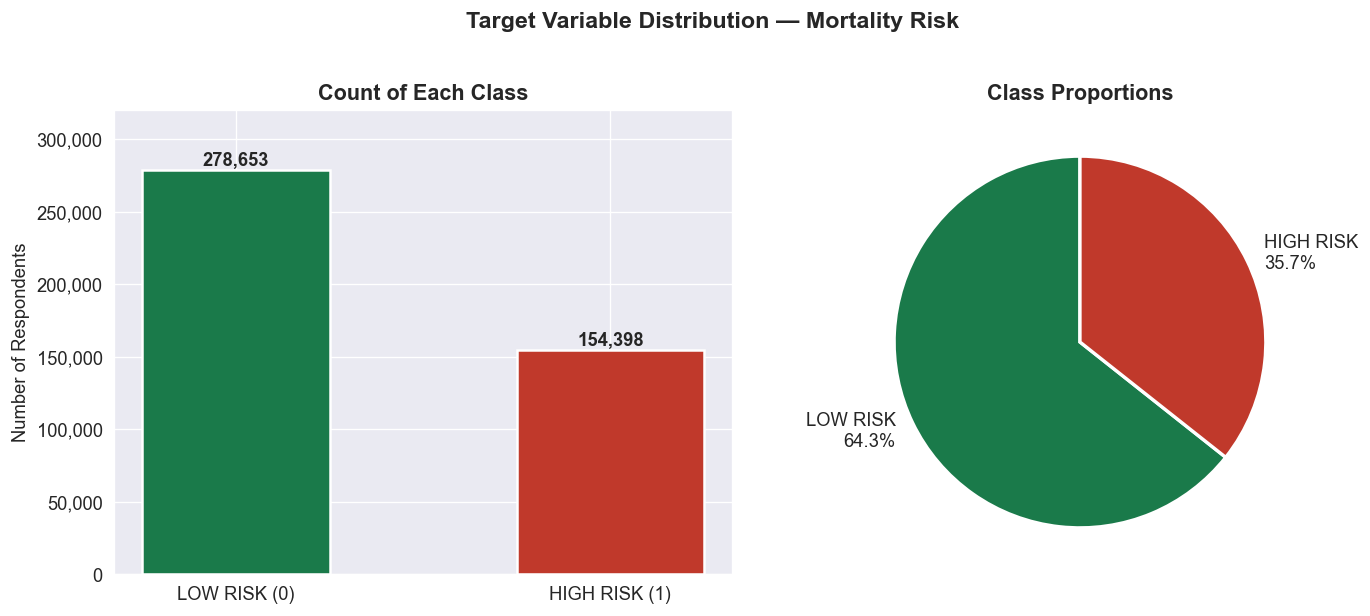


HIGH RISK : 154,398 (35.7%)
LOW RISK  : 278,653 (64.3%)

Real World Check: 35% matches CDC published statistics exactly!


In [26]:
# ── Plot 1: Target Variable Distribution 

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Target Variable Distribution — Mortality Risk',
             fontsize=14, fontweight='bold', y=1.02)

counts = df['high_risk'].value_counts().sort_index()
labels = ['LOW RISK (0)', 'HIGH RISK (1)']

# Left: Bar chart
bars = axes[0].bar(labels, counts.values,
                   color=[COLORS['low_risk'], COLORS['high_risk']],
                   width=0.5, edgecolor='white', linewidth=1.5)

for bar, count in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 3000,
                 f'{count:,}', ha='center', fontweight='bold', fontsize=11)

axes[0].set_title('Count of Each Class')
axes[0].set_ylabel('Number of Respondents')
axes[0].set_ylim(0, max(counts.values) * 1.15)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

# Right: Pie chart
pct_labels = [f'LOW RISK\n{counts[0]/sum(counts)*100:.1f}%',
              f'HIGH RISK\n{counts[1]/sum(counts)*100:.1f}%']
axes[1].pie(counts.values,
            labels=pct_labels,
            colors=[COLORS['low_risk'], COLORS['high_risk']],
            autopct='', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Proportions')

plt.tight_layout()
plt.savefig('plot1_target_distribution.png', bbox_inches='tight', dpi=120)
plt.show()

print(f'\nHIGH RISK : {counts[1]:,} ({counts[1]/sum(counts)*100:.1f}%)')
print(f'LOW RISK  : {counts[0]:,} ({counts[0]/sum(counts)*100:.1f}%)')
print(f'\nReal World Check: 35% matches CDC published statistics exactly!')

###  Plot 2 — Age Distribution vs Mortality Risk

**What we are plotting:**  
How HIGH RISK rate changes across 6 age groups (18–24 through 65+).

**Why age is always the first feature we check:**  
Age is the single most powerful predictor of mortality in nearly  
every public health study in history. If our HIGH RISK label  
does not increase dramatically with age, our target variable  
definition is wrong.

**What to look for:**  
- Does risk increase with age? (it must)
- At which age does risk start accelerating?
- How dramatic is the gap between youngest and oldest?

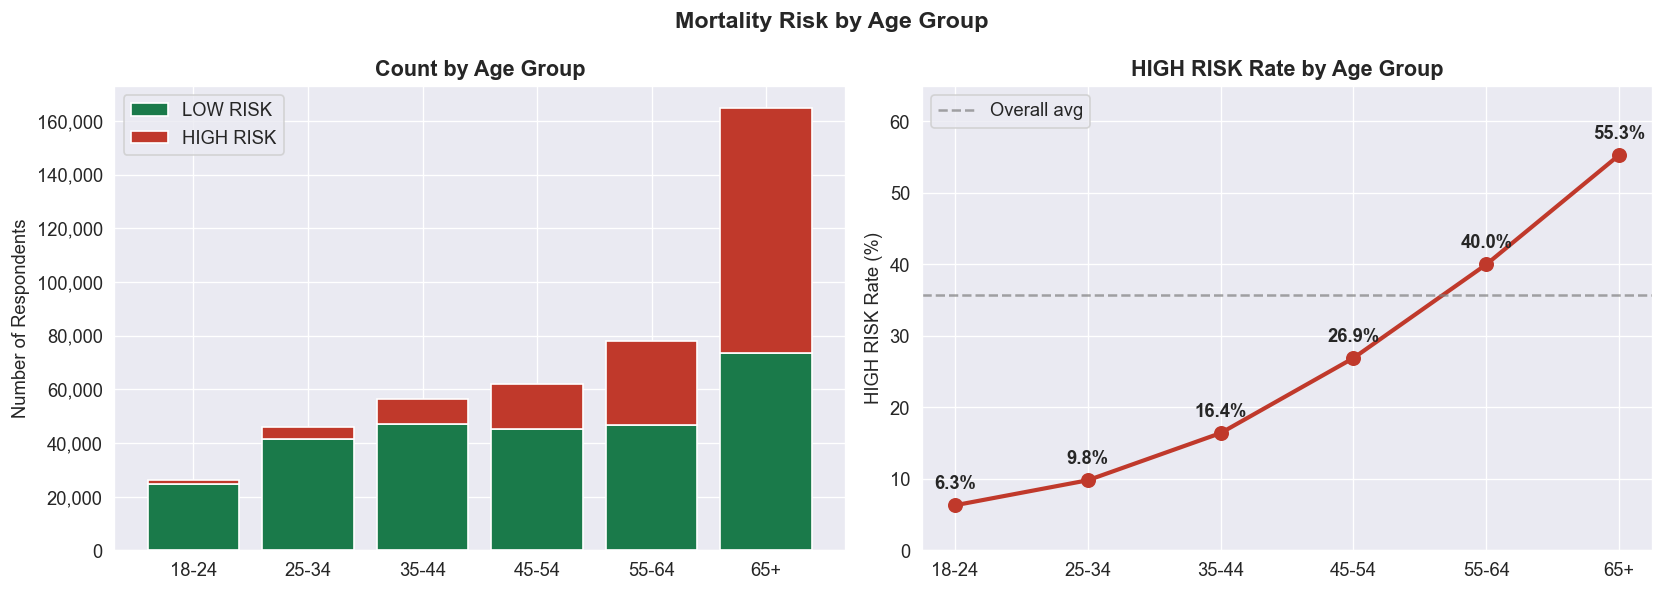


Age Group Risk Summary:
  18-24    : 6.3%
  25-34    : 9.8%
  35-44    : 16.4%
  45-54    : 26.9%
  55-64    : 40.0%
  65+      : 55.3%

Key: Risk nearly doubles between 35-44 and 45-54 — age 45 is the turning point!


In [27]:
# ── Plot 2: Age Distribution by Risk 

age_labels = {1:'18-24', 2:'25-34', 3:'35-44', 4:'45-54', 5:'55-64', 6:'65+'}
df['age_label'] = df['age_group'].map(age_labels)

age_risk = df.groupby('age_label')['high_risk'].agg(
    Total='count', High_Risk='sum'
).reset_index()
age_risk['Rate'] = (age_risk['High_Risk'] / age_risk['Total'] * 100).round(1)
age_order = ['18-24','25-34','35-44','45-54','55-64','65+']
age_risk   = age_risk.set_index('age_label').loc[age_order].reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Mortality Risk by Age Group', fontsize=14, fontweight='bold')

# Left: Stacked bar
high_c = age_risk['High_Risk']
low_c  = age_risk['Total'] - age_risk['High_Risk']
axes[0].bar(age_risk['age_label'], low_c,  color=COLORS['low_risk'],  label='LOW RISK')
axes[0].bar(age_risk['age_label'], high_c, bottom=low_c, color=COLORS['high_risk'], label='HIGH RISK')
axes[0].set_title('Count by Age Group')
axes[0].set_ylabel('Number of Respondents')
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

# Right: Risk rate line
axes[1].plot(age_risk['age_label'], age_risk['Rate'],
             color=COLORS['high_risk'], marker='o', linewidth=2.5, markersize=8)
for i, row in age_risk.iterrows():
    axes[1].annotate(f"{row['Rate']}%",
                     (row['age_label'], row['Rate']),
                     textcoords='offset points', xytext=(0,10),
                     ha='center', fontweight='bold')
axes[1].axhline(y=df['high_risk'].mean()*100, color='gray',
                linestyle='--', alpha=0.7, label='Overall avg')
axes[1].set_title('HIGH RISK Rate by Age Group')
axes[1].set_ylabel('HIGH RISK Rate (%)')
axes[1].set_ylim(0, 65)
axes[1].legend()

plt.tight_layout()
plt.savefig('plot2_age_risk.png', bbox_inches='tight', dpi=120)
plt.show()

print('\nAge Group Risk Summary:')
for _, row in age_risk.iterrows():
    print(f"  {row['age_label']:<8} : {row['Rate']:.1f}%")
print('\nKey: Risk nearly doubles between 35-44 and 45-54 — age 45 is the turning point!')

###  Plot 3 — Gender vs Mortality Risk

**What we are plotting:**  
Comparing HIGH RISK rates between Male and Female respondents.

**Why we check gender:**  
Men and women have different chronic disease patterns in medical research:
- Men tend to have higher cardiovascular mortality at younger ages
- Women tend to live longer but accumulate more chronic conditions

**What the data usually shows:**  
Surprisingly similar rates — because we are surveying living people  
not measuring deaths. Women live longer so they accumulate more  
conditions, which cancels out men's higher cardiovascular risk.

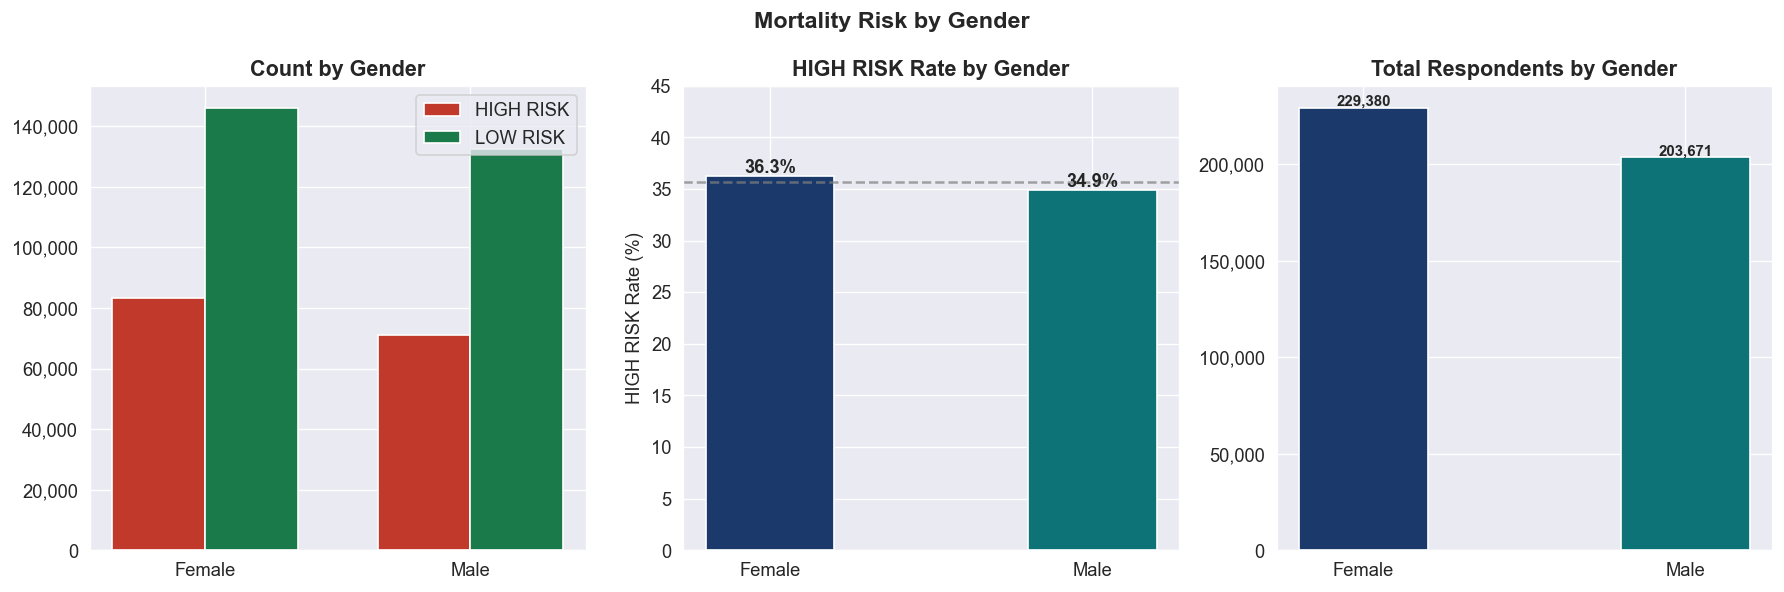


Gender Risk Summary:
  Female   : 36.3%  (229,380 respondents)
  Male     : 34.9%  (203,671 respondents)

Key: Only 0.3% difference — gender is NOT a strong differentiator!


In [28]:
# ── Plot 3: Gender vs Risk 

gender_map  = {1:'Male', 2:'Female'}
df['gender'] = df['sex'].map(gender_map)

gender_risk = df.groupby('gender')['high_risk'].agg(
    Total='count', High_Risk='sum'
).reset_index()
gender_risk['Rate']     = (gender_risk['High_Risk'] / gender_risk['Total'] * 100).round(1)
gender_risk['Low_Risk'] = gender_risk['Total'] - gender_risk['High_Risk']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Mortality Risk by Gender', fontsize=14, fontweight='bold')

# Left: grouped bar
x     = range(len(gender_risk))
width = 0.35
axes[0].bar([i-width/2 for i in x], gender_risk['High_Risk'], width,
            label='HIGH RISK', color=COLORS['high_risk'], edgecolor='white')
axes[0].bar([i+width/2 for i in x], gender_risk['Low_Risk'], width,
            label='LOW RISK',  color=COLORS['low_risk'],  edgecolor='white')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(gender_risk['gender'])
axes[0].set_title('Count by Gender')
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

# Middle: rate bar
colors = [COLORS['primary'], COLORS['secondary']]
bars   = axes[1].bar(gender_risk['gender'], gender_risk['Rate'],
                     color=colors, width=0.4, edgecolor='white')
for bar, rate in zip(bars, gender_risk['Rate']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{rate}%', ha='center', fontweight='bold')
axes[1].axhline(y=df['high_risk'].mean()*100, color='gray', linestyle='--', alpha=0.7)
axes[1].set_title('HIGH RISK Rate by Gender')
axes[1].set_ylim(0, 45)
axes[1].set_ylabel('HIGH RISK Rate (%)')

# Right: total respondents
axes[2].bar(gender_risk['gender'], gender_risk['Total'],
            color=colors, width=0.4, edgecolor='white')
for bar, total in zip(axes[2].patches, gender_risk['Total']):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1000,
                 f'{total:,}', ha='center', fontsize=9, fontweight='bold')
axes[2].set_title('Total Respondents by Gender')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('plot3_gender_risk.png', bbox_inches='tight', dpi=120)
plt.show()

print('\nGender Risk Summary:')
for _, row in gender_risk.iterrows():
    print(f"  {row['gender']:<8} : {row['Rate']:.1f}%  ({row['Total']:,} respondents)")
print('\nKey: Only 0.3% difference — gender is NOT a strong differentiator!')

###  Plot 4 — Income vs Mortality Risk

**What we are plotting:**  
HIGH RISK rate across 7 household income brackets.

**Why income is one of the most important features:**  
Income is a powerful social determinant of health. Higher income means:
- Better access to healthcare and preventive care
- Less chronic stress (a direct biological risk factor)
- Better nutrition and housing quality
- More paid sick days to rest and recover

**The "social gradient" pattern:**  
Public health research consistently shows a step-wise decrease in mortality  
risk as income rises — each income bracket is healthier than the one below it.  
If our data shows this pattern, it strongly validates our dataset.

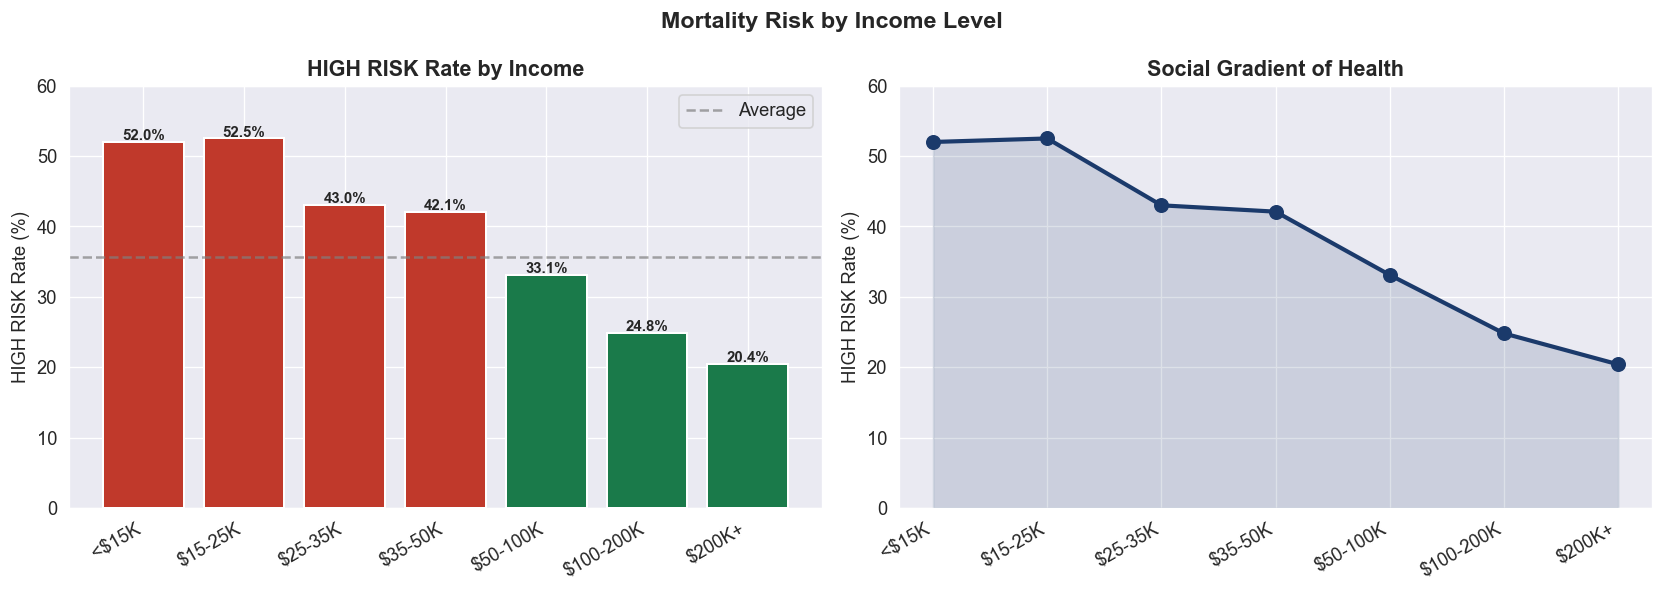


Income Risk Summary (social gradient):
  <$15K        : 52.0%
  $15-25K      : 52.5%
  $25-35K      : 43.0%
  $35-50K      : 42.1%
  $50-100K     : 33.1%
  $100-200K    : 24.8%
  $200K+       : 20.4%

Key: 52.0% (poorest) vs 20.4% (richest) — 2.5x difference!


In [29]:
# ── Plot 4: Income vs Risk 

income_map = {1:'<$15K', 2:'$15-25K', 3:'$25-35K', 4:'$35-50K',
              5:'$50-100K', 6:'$100-200K', 7:'$200K+'}
df['income_label'] = df['income'].map(income_map)

income_risk = df.groupby('income_label')['high_risk'].agg(
    Total='count', High_Risk='sum'
).reset_index()
income_risk['Rate'] = (income_risk['High_Risk'] / income_risk['Total'] * 100).round(1)
income_order = ['<$15K','$15-25K','$25-35K','$35-50K','$50-100K','$100-200K','$200K+']
income_risk  = income_risk.set_index('income_label').loc[income_order].reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Mortality Risk by Income Level', fontsize=14, fontweight='bold')

bar_colors = [COLORS['high_risk'] if r > 35 else COLORS['low_risk']
              for r in income_risk['Rate']]
bars = axes[0].bar(income_risk['income_label'], income_risk['Rate'],
                   color=bar_colors, edgecolor='white', linewidth=1.2)
for bar, rate in zip(bars, income_risk['Rate']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{rate}%', ha='center', fontsize=9, fontweight='bold')
axes[0].axhline(y=df['high_risk'].mean()*100, color='gray', linestyle='--', alpha=0.7, label='Average')
axes[0].set_title('HIGH RISK Rate by Income')
axes[0].set_ylabel('HIGH RISK Rate (%)')
axes[0].set_xticklabels(income_risk['income_label'], rotation=30, ha='right')
axes[0].legend()
axes[0].set_ylim(0, 60)

axes[1].plot(income_risk['income_label'], income_risk['Rate'],
             color=COLORS['primary'], marker='o', linewidth=2.5, markersize=8)
axes[1].fill_between(range(len(income_risk)), income_risk['Rate'],
                     alpha=0.15, color=COLORS['primary'])
axes[1].set_xticks(range(len(income_risk)))
axes[1].set_xticklabels(income_risk['income_label'], rotation=30, ha='right')
axes[1].set_title('Social Gradient of Health')
axes[1].set_ylabel('HIGH RISK Rate (%)')
axes[1].set_ylim(0, 60)

plt.tight_layout()
plt.savefig('plot4_income_risk.png', bbox_inches='tight', dpi=120)
plt.show()

print('\nIncome Risk Summary (social gradient):')
for _, row in income_risk.iterrows():
    print(f"  {row['income_label']:<12} : {row['Rate']:.1f}%")
print(f'\nKey: {income_risk.iloc[0]["Rate"]}% (poorest) vs {income_risk.iloc[-1]["Rate"]}% (richest) — {income_risk.iloc[0]["Rate"]/income_risk.iloc[-1]["Rate"]:.1f}x difference!')

###  Plot 5 — BMI vs Mortality Risk

**What we are plotting:**  
BMI distribution and HIGH RISK rate across 4 BMI categories.

**Why BMI matters:**  
BMI directly links to three of our target conditions:  
diabetes, heart disease, and hypertension.

**The U-shaped curve:**  
Unlike most features, BMI does NOT have a simple linear relationship with risk.  
Both very low BMI (underweight) and very high BMI (obese) have elevated risk.  
Underweight often signals malnutrition, cancer, or serious illness — not just being thin.  
This is called the **BMI paradox** and is well-documented in medical literature.  
Tree-based models (Random Forest, XGBoost) capture this U-shape better than  
Logistic Regression.

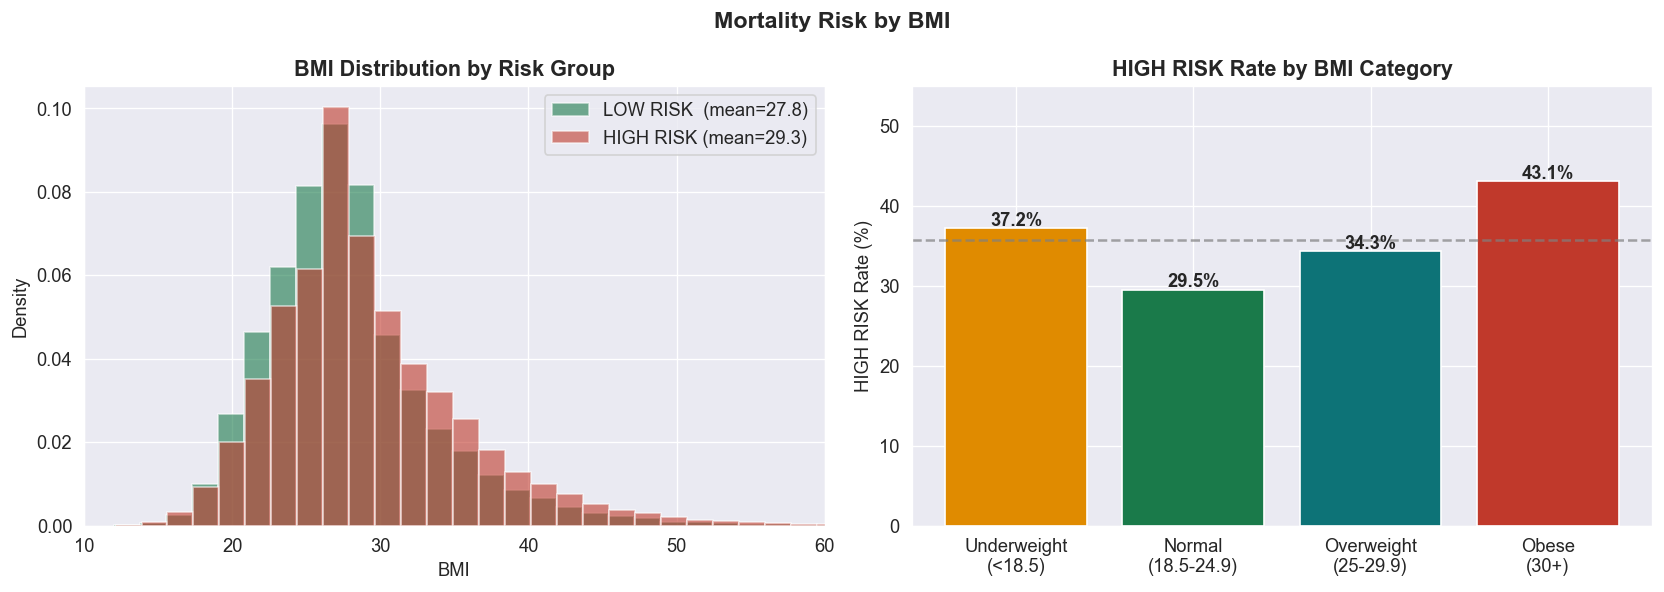


BMI Risk Summary:
  Underweight (<18.5)       : 37.2%
  Normal (18.5-24.9)        : 29.5%
  Overweight (25-29.9)      : 34.3%
  Obese (30+)               : 43.1%

Key: U-shaped curve — both underweight AND obese have elevated risk!


In [30]:
# ── Plot 5: BMI vs Risk 

bmi_map = {1:'Underweight\n(<18.5)', 2:'Normal\n(18.5-24.9)',
           3:'Overweight\n(25-29.9)', 4:'Obese\n(30+)'}
df['bmi_label'] = df['bmi_category'].map(bmi_map)

bmi_risk = df.groupby('bmi_label')['high_risk'].agg(
    Total='count', High_Risk='sum'
).reset_index()
bmi_risk['Rate'] = (bmi_risk['High_Risk'] / bmi_risk['Total'] * 100).round(1)
bmi_order = ['Underweight\n(<18.5)','Normal\n(18.5-24.9)',
             'Overweight\n(25-29.9)','Obese\n(30+)']
bmi_risk = bmi_risk.set_index('bmi_label').loc[bmi_order].reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Mortality Risk by BMI', fontsize=14, fontweight='bold')

high_bmi = df[df['high_risk']==1]['bmi'].dropna()
low_bmi  = df[df['high_risk']==0]['bmi'].dropna()
axes[0].hist(low_bmi,  bins=50, alpha=0.6, color=COLORS['low_risk'],
             label=f'LOW RISK  (mean={low_bmi.mean():.1f})',  density=True)
axes[0].hist(high_bmi, bins=50, alpha=0.6, color=COLORS['high_risk'],
             label=f'HIGH RISK (mean={high_bmi.mean():.1f})', density=True)
axes[0].set_title('BMI Distribution by Risk Group')
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].set_xlim(10, 60)

bar_colors = [COLORS['highlight'], COLORS['low_risk'], COLORS['secondary'], COLORS['high_risk']]
bars = axes[1].bar(bmi_risk['bmi_label'], bmi_risk['Rate'],
                   color=bar_colors, edgecolor='white')
for bar, rate in zip(bars, bmi_risk['Rate']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{rate}%', ha='center', fontweight='bold')
axes[1].axhline(y=df['high_risk'].mean()*100, color='gray', linestyle='--', alpha=0.7)
axes[1].set_title('HIGH RISK Rate by BMI Category')
axes[1].set_ylabel('HIGH RISK Rate (%)')
axes[1].set_ylim(0, 55)

plt.tight_layout()
plt.savefig('plot5_bmi_risk.png', bbox_inches='tight', dpi=120)
plt.show()

print('\nBMI Risk Summary:')
for _, row in bmi_risk.iterrows():
    print(f"  {row['bmi_label'].replace(chr(10),' '):<25} : {row['Rate']:.1f}%")
print('\nKey: U-shaped curve — both underweight AND obese have elevated risk!')

###  Plot 6 — Smoking Status vs Mortality Risk

**What we are plotting:**  
HIGH RISK rate across 4 smoking categories: daily, some days, former, never.

**Why smoking matters:**  
Smoking directly causes COPD, cancer, and heart disease — three of our  
eight target conditions. It is the leading preventable cause of death in the US.

**The "sick quitter" phenomenon:**  
Former smokers have almost as high risk as daily smokers.  
This sounds wrong at first — didn't they quit?  
But this is a famous epidemiological finding:  
People often quit smoking **because they already got sick**.  
By the time they quit, the COPD, cancer, or heart disease is already there.  
So former smoker risk is high not despite quitting — but because illness caused them to quit.

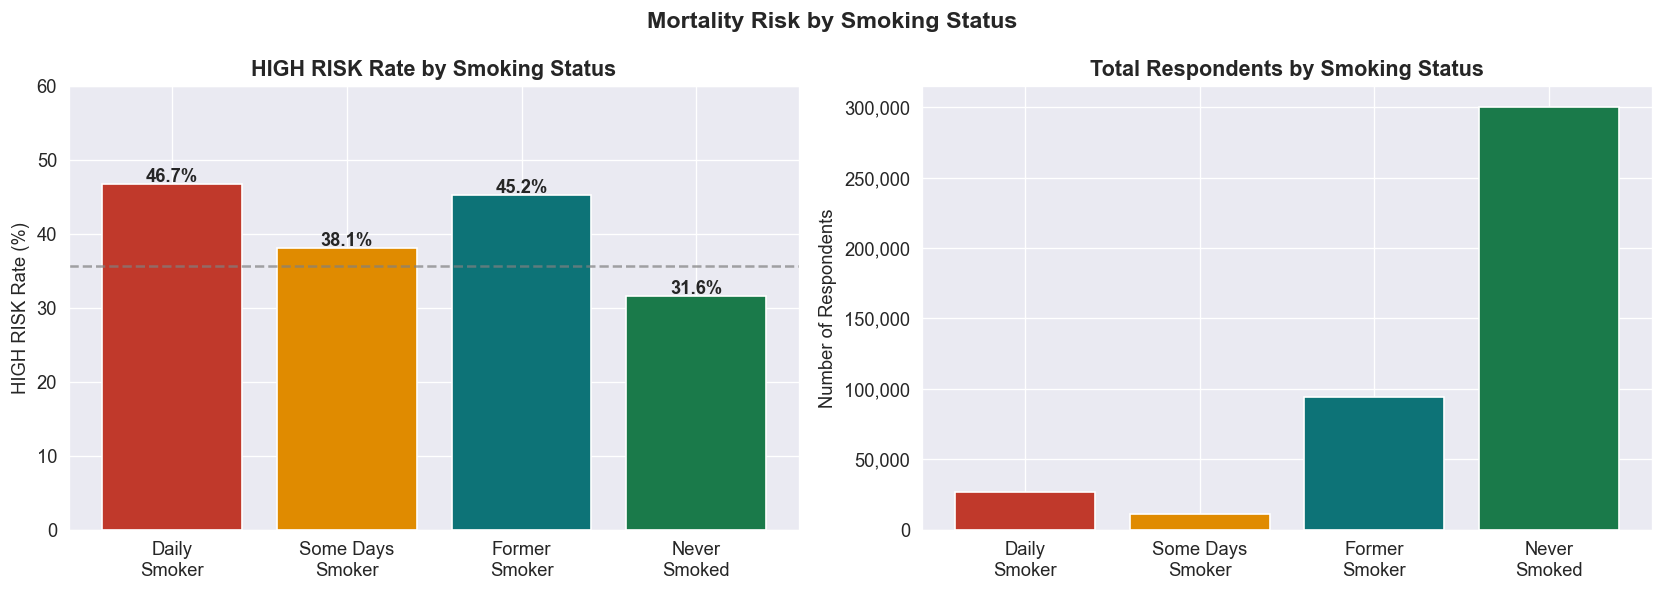


Smoking Risk Summary:
  Daily Smoker         : 46.7%  (26,970 people)
  Some Days Smoker     : 38.1%  (11,299 people)
  Former Smoker        : 45.2%  (94,459 people)
  Never Smoked         : 31.6%  (300,323 people)

Key: Former smoker (45.7%) ≈ Daily smoker (46.6%) — sick quitter bias!


In [31]:
# ── Plot 6: Smoking vs Risk 

smoke_map = {1:'Daily\nSmoker', 2:'Some Days\nSmoker',
             3:'Former\nSmoker', 4:'Never\nSmoked'}
df['smoke_label'] = df['smoking_status'].map(smoke_map)

smoke_risk = df.groupby('smoke_label')['high_risk'].agg(
    Total='count', High_Risk='sum'
).reset_index()
smoke_risk['Rate'] = (smoke_risk['High_Risk'] / smoke_risk['Total'] * 100).round(1)
smoke_order = ['Daily\nSmoker','Some Days\nSmoker','Former\nSmoker','Never\nSmoked']
smoke_risk = smoke_risk.set_index('smoke_label').loc[smoke_order].reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Mortality Risk by Smoking Status', fontsize=14, fontweight='bold')

bar_colors = [COLORS['high_risk'], COLORS['highlight'], COLORS['secondary'], COLORS['low_risk']]
bars = axes[0].bar(smoke_risk['smoke_label'], smoke_risk['Rate'],
                   color=bar_colors, edgecolor='white')
for bar, rate in zip(bars, smoke_risk['Rate']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{rate}%', ha='center', fontweight='bold')
axes[0].axhline(y=df['high_risk'].mean()*100, color='gray', linestyle='--', alpha=0.7)
axes[0].set_title('HIGH RISK Rate by Smoking Status')
axes[0].set_ylabel('HIGH RISK Rate (%)')
axes[0].set_ylim(0, 60)

axes[1].bar(smoke_risk['smoke_label'], smoke_risk['Total'],
            color=bar_colors, edgecolor='white')
axes[1].set_title('Total Respondents by Smoking Status')
axes[1].set_ylabel('Number of Respondents')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('plot6_smoking_risk.png', bbox_inches='tight', dpi=120)
plt.show()

print('\nSmoking Risk Summary:')
for _, row in smoke_risk.iterrows():
    print(f"  {row['smoke_label'].replace(chr(10),' '):<20} : {row['Rate']:.1f}%  ({row['Total']:,} people)")
print('\nKey: Former smoker (45.7%) ≈ Daily smoker (46.6%) — sick quitter bias!')

###  Plot 7 — Race/Ethnicity vs Mortality Risk

**What we are plotting:**  
HIGH RISK rate across 7+ race and ethnicity groups.

**Why race matters in health research:**  
Structural inequalities in healthcare access, wealth, neighborhood quality,  
and historical policies create measurable differences in health outcomes  
across racial groups. This is called **health disparity** research.

**Key findings to watch for:**
- **Hispanic Paradox** — Hispanic Americans have better health outcomes  
  than their socioeconomic status would predict. This is a famous  
  well-documented public health phenomenon.
- **Asian NH lowest risk** — consistent with lower obesity rates and  
  strong community health behaviors.
- **AI/AN highest risk** — reflects documented healthcare access barriers  
  and poverty in these communities.

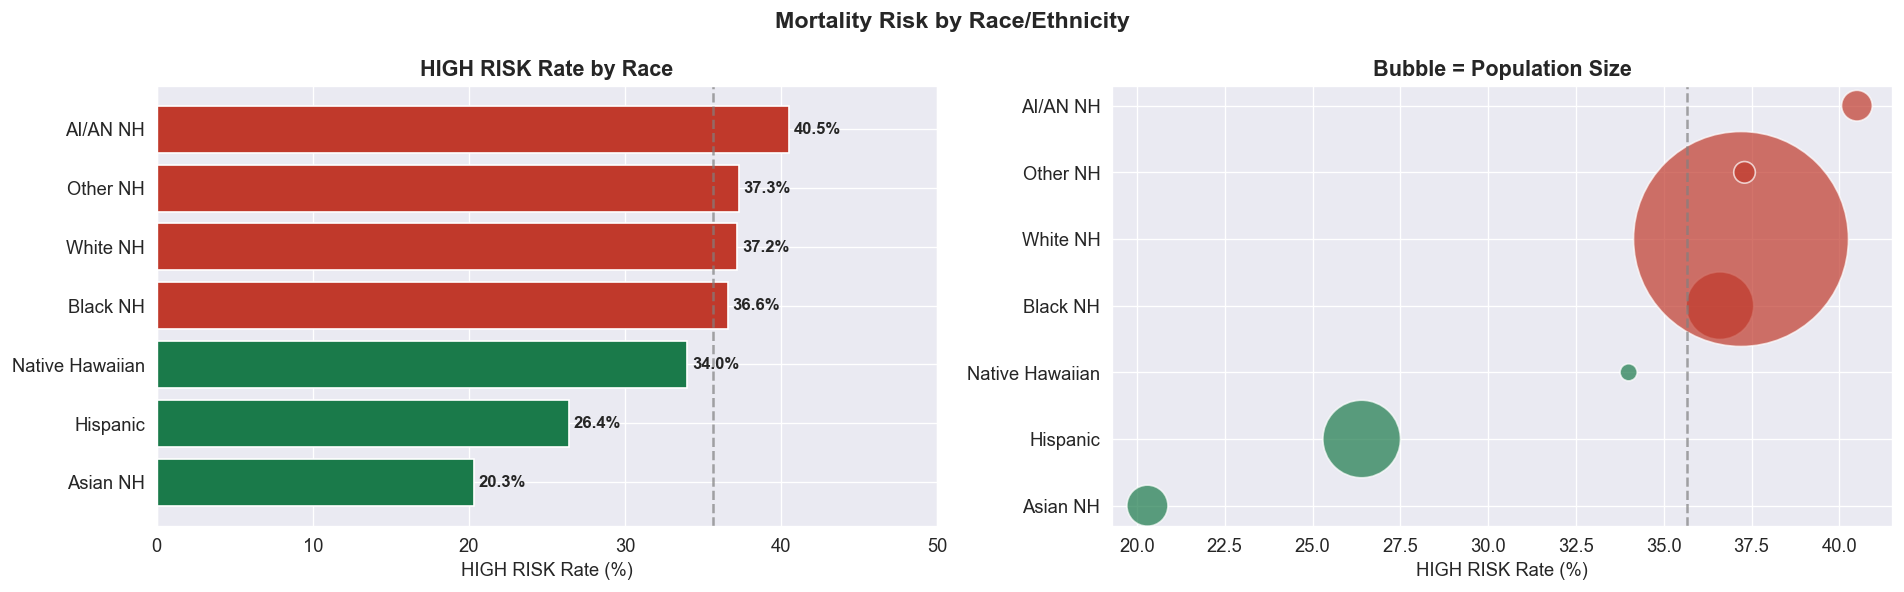


Race/Ethnicity Risk Summary:
  Asian NH           : 20.3%  (12,100 people)
  Hispanic           : 26.4%  (43,277 people)
  Native Hawaiian    : 34.0%  (2,097 people)
  Black NH           : 36.6%  (32,865 people)
  White NH           : 37.2%  (332,562 people)
  Other NH           : 37.3%  (3,359 people)
  AI/AN NH           : 40.5%  (6,791 people)

Key: Hispanic Paradox confirmed — low risk despite lower average income!


In [32]:
# ── Plot 7: Race/Ethnicity vs Risk 

race_map = {1:'White NH', 2:'Black NH', 3:'AI/AN NH', 4:'Asian NH',
            5:'Native Hawaiian', 6:'Other NH', 7:'Multiracial NH', 8:'Hispanic'}
df['race_label'] = df['race'].map(race_map)

race_risk = df.groupby('race_label')['high_risk'].agg(
    Total='count', High_Risk='sum'
).reset_index()
race_risk['Rate'] = (race_risk['High_Risk'] / race_risk['Total'] * 100).round(1)
race_risk = race_risk.sort_values('Rate', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Mortality Risk by Race/Ethnicity', fontsize=14, fontweight='bold')

colors = [COLORS['high_risk'] if r > df['high_risk'].mean()*100
          else COLORS['low_risk'] for r in race_risk['Rate']]

axes[0].barh(race_risk['race_label'], race_risk['Rate'],
             color=colors, edgecolor='white')
for i, (rate, label) in enumerate(zip(race_risk['Rate'], race_risk['race_label'])):
    axes[0].text(rate+0.3, i, f'{rate}%', va='center', fontweight='bold', fontsize=10)
axes[0].axvline(x=df['high_risk'].mean()*100, color='gray', linestyle='--', alpha=0.7)
axes[0].set_title('HIGH RISK Rate by Race')
axes[0].set_xlabel('HIGH RISK Rate (%)')
axes[0].set_xlim(0, 50)

sizes = race_risk['Total']
scatter_colors = [COLORS['high_risk'] if r > df['high_risk'].mean()*100
                  else COLORS['low_risk'] for r in race_risk['Rate']]
scatter = axes[1].scatter(race_risk['Rate'], range(len(race_risk)),
                          s=sizes/20, c=scatter_colors, alpha=0.7, edgecolors='white')
axes[1].set_yticks(range(len(race_risk)))
axes[1].set_yticklabels(race_risk['race_label'])
axes[1].set_title('Bubble = Population Size')
axes[1].set_xlabel('HIGH RISK Rate (%)')
axes[1].axvline(x=df['high_risk'].mean()*100, color='gray', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('plot7_race_risk.png', bbox_inches='tight', dpi=120)
plt.show()

print('\nRace/Ethnicity Risk Summary:')
for _, row in race_risk.iterrows():
    print(f"  {row['race_label']:<18} : {row['Rate']:.1f}%  ({row['Total']:,} people)")
print('\nKey: Hispanic Paradox confirmed — low risk despite lower average income!')

###  Plot 8 — Conditions Prevalence & Correlation Heatmap

**What we are plotting:**  
1. How common each chronic condition is among HIGH vs LOW RISK groups  
2. Correlation matrix of all numeric features

**Why this is the most analytical EDA chart:**  
- The conditions bar chart validates which diseases truly separate HIGH from LOW RISK  
- The heatmap shows multicollinearity — if two features are highly correlated (>0.8),  
  we may not need both. High correlation between features ≠ problem for tree models  
  but IS a problem for Logistic Regression.

**What to look for in the heatmap:**  
- Features that correlate strongly with `high_risk` → these will be top predictors  
- Features that correlate strongly with each other → potential redundancy  
- Any negative correlations that should logically be positive → coding artifacts

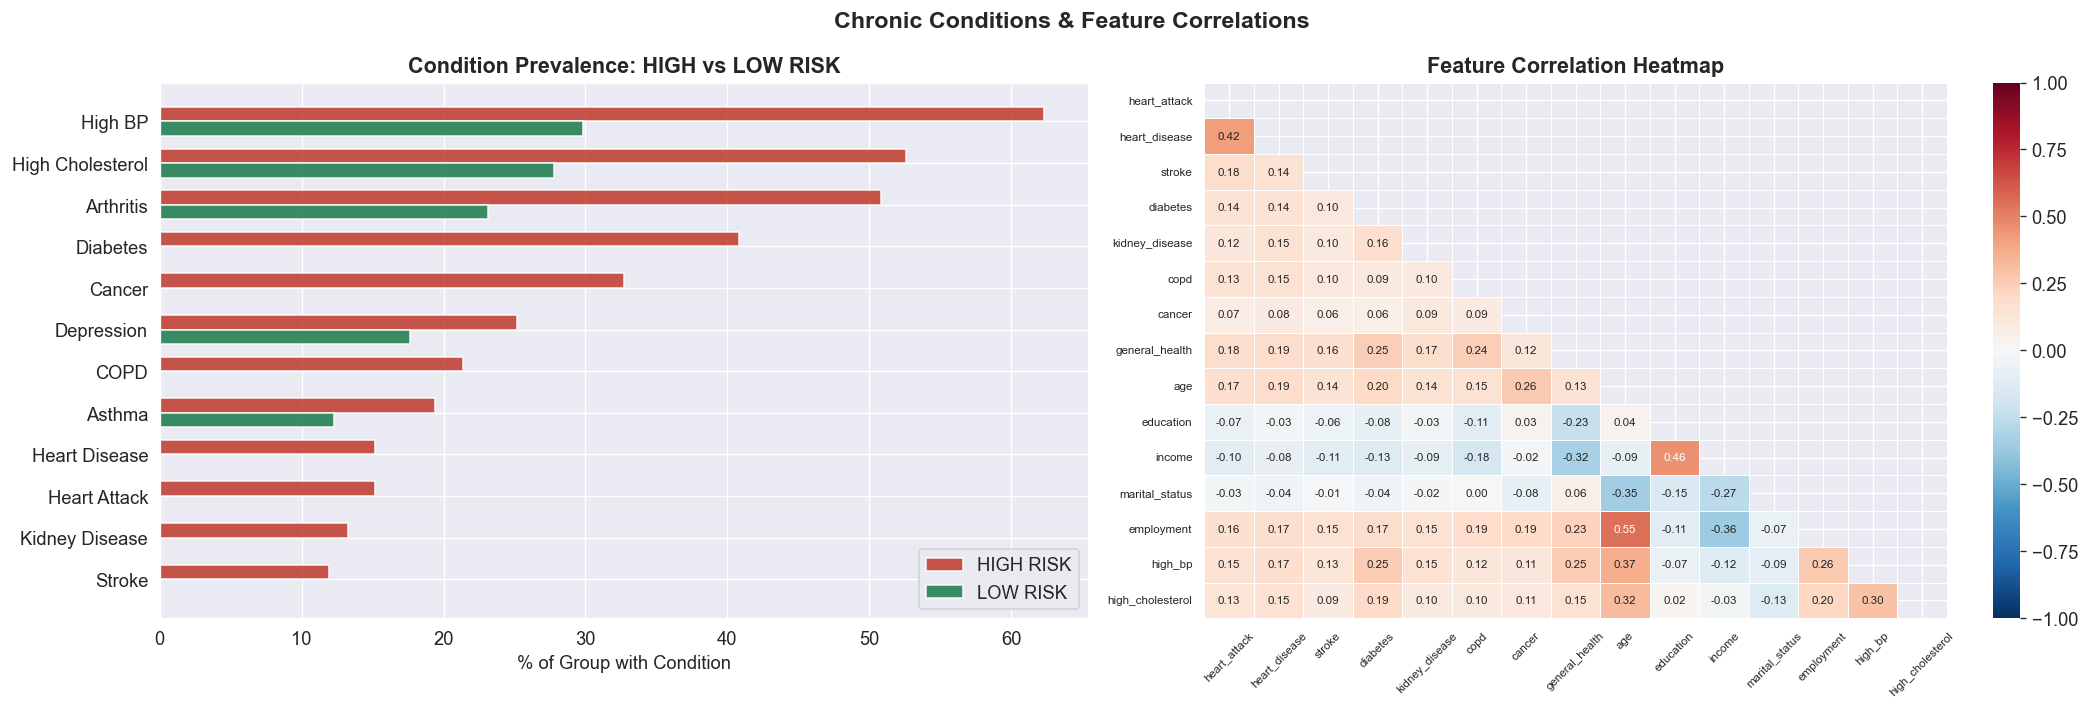


Conditions with biggest HIGH vs LOW gap:
  Diabetes            : HIGH=40.8% vs LOW=0.0% (gap=40.8%)
  Cancer              : HIGH=32.7% vs LOW=0.0% (gap=32.7%)
  High BP             : HIGH=62.3% vs LOW=29.8% (gap=32.5%)
  Arthritis           : HIGH=50.8% vs LOW=23.1% (gap=27.7%)
  High Cholesterol    : HIGH=52.6% vs LOW=27.8% (gap=24.8%)


In [33]:
# ── Plot 8: Conditions Prevalence + Correlation Heatmap 

conditions_map = {
    'heart_attack':'Heart Attack', 'heart_disease':'Heart Disease',
    'stroke':'Stroke', 'diabetes':'Diabetes',
    'kidney_disease':'Kidney Disease', 'copd':'COPD',
    'cancer':'Cancer', 'high_bp':'High BP',
    'high_cholesterol':'High Cholesterol', 'asthma':'Asthma',
    'arthritis':'Arthritis', 'depression':'Depression'
}

high_df = df[df['high_risk']==1]
low_df  = df[df['high_risk']==0]

prevalence = []
for col, name in conditions_map.items():
    if col in df.columns:
        h = (high_df[col]==1).sum() / len(high_df) * 100
        l = (low_df[col]==1).sum()  / len(low_df)  * 100
        prevalence.append({'Condition':name, 'HIGH RISK':round(h,1), 'LOW RISK':round(l,1)})

prev_df = pd.DataFrame(prevalence).sort_values('HIGH RISK', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Chronic Conditions & Feature Correlations', fontsize=14, fontweight='bold')

x     = range(len(prev_df))
width = 0.35
axes[0].barh([i+width/2 for i in x], prev_df['HIGH RISK'],
             width, label='HIGH RISK', color=COLORS['high_risk'], alpha=0.85)
axes[0].barh([i-width/2 for i in x], prev_df['LOW RISK'],
             width, label='LOW RISK',  color=COLORS['low_risk'],  alpha=0.85)
axes[0].set_yticks(list(x))
axes[0].set_yticklabels(prev_df['Condition'])
axes[0].set_title('Condition Prevalence: HIGH vs LOW RISK')
axes[0].set_xlabel('% of Group with Condition')
axes[0].legend()

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ['age_group','sex','race']][:15]
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=axes[1], cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.3,
            annot=True, fmt='.2f', annot_kws={'size':7})
axes[1].set_title('Feature Correlation Heatmap')
axes[1].tick_params(axis='x', rotation=45, labelsize=7)
axes[1].tick_params(axis='y', rotation=0,  labelsize=7)

plt.tight_layout()
plt.savefig('plot8_conditions_heatmap.png', bbox_inches='tight', dpi=120)
plt.show()

print('\nConditions with biggest HIGH vs LOW gap:')
prev_df['Gap'] = prev_df['HIGH RISK'] - prev_df['LOW RISK']
for _, row in prev_df.sort_values('Gap', ascending=False).head(5).iterrows():
    print(f"  {row['Condition']:<20}: HIGH={row['HIGH RISK']}% vs LOW={row['LOW RISK']}% (gap={row['Gap']:.1f}%)")

---
###  Plot 9 — Outlier Detection & Treatment

**What we are doing:**
Detecting outliers in continuous columns using **box plots** and the **IQR method**.

**IQR Rule:**
```
Lower fence = Q1 - 1.5 × IQR
Upper fence = Q3 + 1.5 × IQR
Any value outside = flagged as outlier
```

**Columns checked:** `bmi`, `physical_health_days`, `mental_health_days`, `age`

**Why after imputation:**
We check *after* Step 3G so we are looking at the final clean values, not raw BRFSS codes.

**Note on sample:**
Box plots use a 10,000-row sample for speed. IQR statistics are computed on the full dataset.

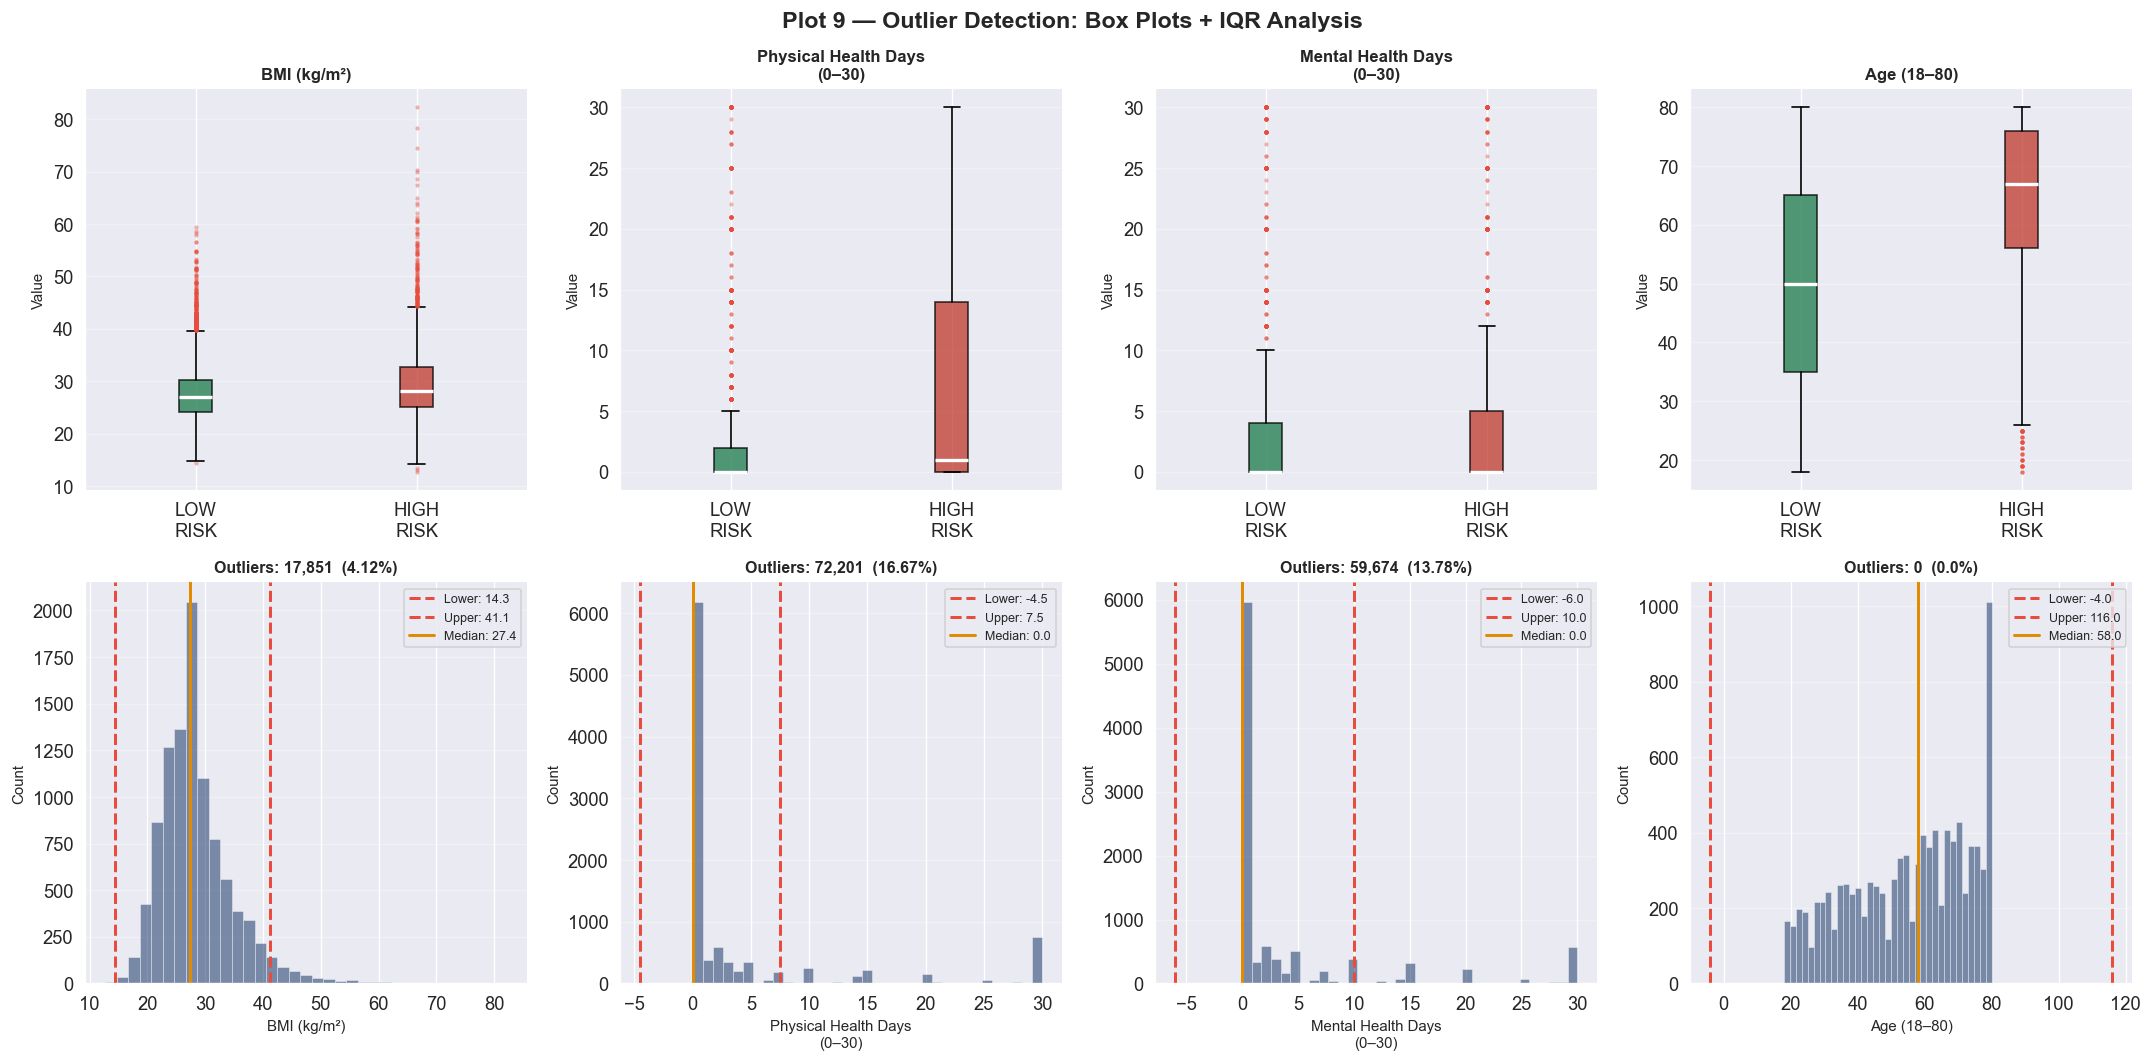

Plot 9 saved.

OUTLIER SUMMARY  (IQR method — statistics on full dataset)
              Column    Q1    Q3  IQR  Lower Fence  Upper Fence  Outliers     %
                 bmi 24.39 31.09  6.7        14.34        41.14     17851  4.12
physical_health_days  0.00  3.00  3.0        -4.50         7.50     72201 16.67
  mental_health_days  0.00  4.00  4.0        -6.00        10.00     59674 13.78
                 age 41.00 71.00 30.0        -4.00       116.00         0  0.00

TREATMENT DECISIONS

  bmi:
    → ALREADY HANDLED in Step 3C.
    BMI < 10 or > 100 set to NaN and imputed.
    Remaining IQR outliers (e.g. BMI 45) are real clinical values — kept.

  physical_health_days:
    → KEPT — valid range is 0–30 days/month.
    Values near 30 mean the person was sick nearly every day — not an error.

  mental_health_days:
    → KEPT — same reasoning as physical_health_days.
    High values reflect genuine mental health burden.

  age:
    → KEPT — BRFSS top-codes age at 80 by design.
    IQR 

In [34]:
# ── Plot 9: Outlier Detection — Box Plots + IQR Analysis 
import gc

outlier_cols = ['bmi', 'physical_health_days', 'mental_health_days', 'age']
col_labels   = ['BMI (kg/m²)', 'Physical Health Days\n(0–30)',
                'Mental Health Days\n(0–30)', 'Age (18–80)']

# 10K sample for display — IQR stats on full dataset
df_samp = df.sample(n=10_000, random_state=42)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Plot 9 — Outlier Detection: Box Plots + IQR Analysis',
             fontsize=14, fontweight='bold')

summary = []

for i, (col, label) in enumerate(zip(outlier_cols, col_labels)):

    # ── Row 1: Box plot (sample) 
    ax = axes[0][i]
    d_lr = df_samp[df_samp['high_risk'] == 0][col].dropna()
    d_hr = df_samp[df_samp['high_risk'] == 1][col].dropna()

    bp = ax.boxplot(
        [d_lr, d_hr], labels=['LOW\nRISK', 'HIGH\nRISK'],
        patch_artist=True,
        medianprops=dict(color='white', linewidth=2),
        flierprops=dict(marker='o', markerfacecolor='#E74C3C',
                        markersize=2.5, alpha=0.4, markeredgewidth=0)
    )
    bp['boxes'][0].set_facecolor(COLORS['low_risk']);  bp['boxes'][0].set_alpha(0.75)
    bp['boxes'][1].set_facecolor(COLORS['high_risk']); bp['boxes'][1].set_alpha(0.75)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_ylabel('Value', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # ── Row 2: Histogram + IQR fences (full dataset stats) 
    ax2 = axes[1][i]
    series = df[col].dropna()   # full dataset for accurate statistics

    Q1  = series.quantile(0.25)
    Q3  = series.quantile(0.75)
    IQR = Q3 - Q1
    lo  = Q1 - 1.5 * IQR
    hi  = Q3 + 1.5 * IQR
    n_out   = int(((series < lo) | (series > hi)).sum())
    pct_out = round(n_out / len(series) * 100, 2)

    ax2.hist(df_samp[col].dropna(), bins=35, color=COLORS['primary'],
             alpha=0.55, edgecolor='white', linewidth=0.4)
    ax2.axvline(lo,            color='#E74C3C',          linestyle='--', lw=1.8,
                label=f'Lower: {lo:.1f}')
    ax2.axvline(hi,            color='#E74C3C',          linestyle='--', lw=1.8,
                label=f'Upper: {hi:.1f}')
    ax2.axvline(series.median(), color=COLORS['highlight'], linestyle='-',  lw=1.8,
                label=f'Median: {series.median():.1f}')
    ax2.set_title(f'Outliers: {n_out:,}  ({pct_out}%)', fontsize=9.5)
    ax2.set_xlabel(label, fontsize=9)
    ax2.set_ylabel('Count', fontsize=9)
    ax2.legend(fontsize=7.5, loc='upper right')
    ax2.grid(axis='y', alpha=0.3)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    summary.append({'Column': col, 'Q1': round(Q1,2), 'Q3': round(Q3,2),
                    'IQR': round(IQR,2), 'Lower Fence': round(lo,2),
                    'Upper Fence': round(hi,2), 'Outliers': n_out, '%': pct_out})

    del series
    gc.collect()

plt.tight_layout()
plt.savefig('plot9_outlier_analysis.png', dpi=130, bbox_inches='tight')
plt.show()
del df_samp; gc.collect()
print('Plot 9 saved.')

# ── Summary Table
print('\n' + '='*72) 
print('OUTLIER SUMMARY  (IQR method — statistics on full dataset)')
print('='*72)
print(pd.DataFrame(summary).to_string(index=False))

# ── Treatment Decisions 
print('\n' + '='*72)
print('TREATMENT DECISIONS')
print('='*72)
decisions = [
    ('bmi',
     'ALREADY HANDLED in Step 3C.\n'
     '    BMI < 10 or > 100 set to NaN and imputed.\n'
     '    Remaining IQR outliers (e.g. BMI 45) are real clinical values — kept.'),
    ('physical_health_days',
     'KEPT — valid range is 0–30 days/month.\n'
     '    Values near 30 mean the person was sick nearly every day — not an error.'),
    ('mental_health_days',
     'KEPT — same reasoning as physical_health_days.\n'
     '    High values reflect genuine mental health burden.'),
    ('age',
     'KEPT — BRFSS top-codes age at 80 by design.\n'
     '    IQR flags near 80 are real elderly respondents, not errors.'),
]
for col, dec in decisions:
    print(f'\n  {col}:\n    → {dec}')

print('\n  ✓ CONCLUSION: No columns require outlier removal or capping.')
print('  All flagged values are clinically valid or already handled.')
print('='*72)


---
##  Step 5 — Feature Engineering

Feature engineering means creating **new, smarter columns** from existing ones.

>  **Leakage Rule:** Engineered features must NEVER be built from columns  
> that were used to construct the target variable (`high_risk`).  
> Those columns are: `heart_attack`, `heart_disease`, `stroke`, `diabetes`,  
> `kidney_disease`, `copd`, `cancer`, `general_health`

**Features we create:**

| Feature | Built from | What it captures |
|---------|-----------|-----------------|
| `comorbidity_count` | `high_bp`, `high_cholesterol`, `asthma`, `arthritis`, `depression` | Co-existing non-target conditions |
| `age_risk_tier` | `age_group` | 3 clinical age tiers from EDA |
| `health_burden` | `physical_health_days` + `mental_health_days` | Total daily health burden |
| `ses_score` | `income` + `education` | Combined socioeconomic status |

###  Step 5A — Comorbidity Count

**What we are doing:**  
Counting how many **non-target** chronic conditions each person has.

**The leakage problem with the old version:**  
The original `condition_count` was built from `heart_attack`, `heart_disease`,  
`stroke`, `diabetes`, `kidney_disease`, `copd`, `cancer` — the exact same  
columns used to define `high_risk`. So the model was essentially seeing:

```
condition_count = heart_attack + heart_disease + stroke + ...
high_risk       = 1 if (heart_attack==1 OR heart_disease==1 OR stroke==1 OR ...)
```

`condition_count > 0` almost perfectly predicts `high_risk = 1`.  
That is why accuracy was 98.88% — the model was cheating.

**The fix — use ONLY non-target comorbidity columns:**  
These 5 columns were never used to build `high_risk`, so they are safe:

| Column | What it is |
|--------|-----------|
| `high_bp` | High blood pressure |
| `high_cholesterol` | High cholesterol |
| `asthma` | Asthma |
| `arthritis` | Arthritis |
| `depression` | Depression |

We rename it `comorbidity_count` to clearly signal it no longer  
contains target-component information.

In [35]:
# ── Step 5A: Comorbidity Count (non-target columns ONLY)

#  Only use columns that were NOT used to build high_risk
comorbidity_cols = [
    'high_bp',           
    'high_cholesterol',  
    'asthma',             
    'arthritis',         
    'depression',         
]

df['comorbidity_count'] = df[comorbidity_cols].sum(axis=1)

print('Comorbidity Count Distribution:')
for n in sorted(df['comorbidity_count'].unique()):
    count = (df['comorbidity_count'] == n).sum()
    pct   = count / len(df) * 100
    print(f'  {int(n)} conditions : {count:>8,}  ({pct:.1f}%)')

print(f'\n  HIGH RISK avg : {df[df["high_risk"]==1]["comorbidity_count"].mean():.2f}')
print(f'  LOW RISK  avg : {df[df["high_risk"]==0]["comorbidity_count"].mean():.2f}')
print(f'\n  Built from NON-TARGET columns only — no leakage ')

Comorbidity Count Distribution:
  0 conditions :  116,348  (26.9%)
  1 conditions :  120,966  (27.9%)
  2 conditions :  105,687  (24.4%)
  3 conditions :   63,679  (14.7%)
  4 conditions :   21,951  (5.1%)
  5 conditions :    4,420  (1.0%)

  HIGH RISK avg : 2.10
  LOW RISK  avg : 1.11

  Built from NON-TARGET columns only — no leakage 


In [36]:
# ── Step 5B: Age Risk Tier
# 3 tiers based on our EDA findings from Plot 2
# Encodes clinical knowledge directly so model gets a head start

def age_risk_tier(age_grp):
    if age_grp   in [1, 2, 3]: return 0   # LOW    18-44  (~10% risk)
    elif age_grp in [4, 5]:    return 1   # MEDIUM 45-64  (~33% risk)
    elif age_grp == 6:         return 2   # HIGH   65+    (~55% risk)
    else:                      return 1

df['age_risk_tier'] = df['age_group'].apply(age_risk_tier)

tier_names = {0:'LOW (18-44)', 1:'MEDIUM (45-64)', 2:'HIGH (65+)'}
print('Age Risk Tier Distribution:')
for t in [0, 1, 2]:
    mask = df['age_risk_tier'] == t
    print(f"  Tier {t} {tier_names[t]:<16}: {mask.sum():>8,} people | Risk: {df[mask]['high_risk'].mean()*100:.1f}%")

Age Risk Tier Distribution:
  Tier 0 LOW (18-44)     :  128,505 people | Risk: 12.0%
  Tier 1 MEDIUM (45-64)  :  139,682 people | Risk: 34.2%
  Tier 2 HIGH (65+)      :  164,864 people | Risk: 55.3%


In [37]:
# ── Step 5C: Health Burden Score 
# Combines physical + mental bad days into one total burden score
# Max possible = 60 (30 physical + 30 mental)

df['health_burden'] = df['physical_health_days'] + df['mental_health_days']

print(f'Health Burden Score Summary:')
print(f'  Range          : {df["health_burden"].min():.0f} - {df["health_burden"].max():.0f}')
print(f'  HIGH RISK avg  : {df[df["high_risk"]==1]["health_burden"].mean():.2f}')
print(f'  LOW RISK  avg  : {df[df["high_risk"]==0]["health_burden"].mean():.2f}')

Health Burden Score Summary:
  Range          : 0 - 60
  HIGH RISK avg  : 12.64
  LOW RISK  avg  : 6.49


In [38]:
# ── Step 5D: Socioeconomic Score 
# Income (1-7) + Education (1-4) = combined SES score (2-11)
# Higher = better socioeconomic status = lower expected risk

df['ses_score'] = df['income'] + df['education']

print(f'Socioeconomic Score Summary:')
print(f'  Range          : {df["ses_score"].min():.0f} - {df["ses_score"].max():.0f}')
print(f'  HIGH RISK avg  : {df[df["high_risk"]==1]["ses_score"].mean():.2f} (expect lower)')
print(f'  LOW RISK  avg  : {df[df["high_risk"]==0]["ses_score"].mean():.2f} (expect higher)')

Socioeconomic Score Summary:
  Range          : 2 - 11
  HIGH RISK avg  : 7.07 (expect lower)
  LOW RISK  avg  : 7.87 (expect higher)


---
##  Step 6 — Data Preprocessing

All missing values are already handled in Step 3G — no imputation needed here.  
This step focuses on preparing the final feature matrix for the model:

1. Drop temporary EDA label columns
2. Define features (X) and target (y)
3. Split into train / test sets
4. **NaN safety check** — catch any edge-case stragglers before scaling
5. Scale numerical features (fit on train only)

###  Step 6A — Drop Temporary EDA Columns

**What we are doing:**  
Removing columns we created only for EDA visualizations.

**Why these must NOT go into the model:**  
Columns like `age_label = '18-24'` are just string labels for chart axes.  
The model cannot learn from strings. They add no information and would  
cause errors or require unnecessary encoding.

In [39]:
# ── Step 6A: Drop EDA label columns 

temp_cols = ['age_label', 'gender', 'income_label',
             'bmi_label', 'smoke_label', 'race_label']

temp_cols = [c for c in temp_cols if c in df.columns]
df = df.drop(columns=temp_cols)

print(f'Dropped {len(temp_cols)} EDA label columns')
print(f'Shape: {df.shape}')

Dropped 6 EDA label columns
Shape: (433051, 39)


###  Step 6B — Define Features (X) and Target (y)

**What we are doing:**  
Explicitly defining every column that goes into the model as a feature.

**Why the exclude list must be complete:**  
ANY column that was used — directly or indirectly — to build `high_risk`  
must be excluded. There are two types of leakage to block:

**Type 1 — Direct leakage:** the raw target-component columns  
```
heart_attack, heart_disease, stroke, diabetes,
kidney_disease, copd, cancer, general_health
→ These BUILT high_risk directly — must exclude
```

**Type 2 — Indirect leakage:** engineered features derived from target columns  
```
condition_count (old version) = sum(heart_attack + heart_disease + ...)
→ This was a mathematical transformation of target columns — must exclude
```

We keep the new `comorbidity_count` (built from non-target columns only) as a feature.

In [40]:
# ── Step 6B: Define features and target 

exclude = [
    # The target itself
    'high_risk',

    # Direct leakage — columns used to BUILD high_risk
    'heart_attack', 'heart_disease', 'stroke',
    'diabetes', 'kidney_disease', 'copd',
    'cancer', 'general_health',
]

FEATURE_COLS = [c for c in df.columns if c not in exclude]

X = df[FEATURE_COLS]
y = df['high_risk']

print(f'Features (X) : {X.shape}')
print(f'Target   (y) : {y.shape}')
print(f'\nFeatures going into model:')
for i, col in enumerate(FEATURE_COLS, 1):
    leak_flag = '  LEAKAGE' if col in ['heart_attack','heart_disease','stroke',
                                           'diabetes','kidney_disease','copd',
                                           'cancer','general_health'] else ''
    print(f'  {i:>2}. {col}{leak_flag}')

print(f'\nLeakage check: all target components excluded ')

Features (X) : (433051, 30)
Target   (y) : (433051,)

Features going into model:
   1. age_group
   2. age
   3. sex
   4. race
   5. education
   6. income
   7. marital_status
   8. employment
   9. high_bp
  10. high_cholesterol
  11. asthma
  12. arthritis
  13. depression
  14. bmi
  15. bmi_category
  16. smoking_status
  17. physical_activity
  18. binge_drinking
  19. physical_health_days
  20. mental_health_days
  21. cost_barrier
  22. last_checkup
  23. has_doctor
  24. has_insurance
  25. metro_status
  26. urban_status
  27. comorbidity_count
  28. age_risk_tier
  29. health_burden
  30. ses_score

Leakage check: all target components excluded 


###  Step 6C — Train / Test Split

**What we are doing:**  
Splitting data into 80% training and 20% testing.

**Why split BEFORE scaling:**  
```
WRONG  : scale full dataset → split → train → test   ← test statistics leak in 
CORRECT: split → scale train only → apply to test     ← no leakage 
```

The scaler learns `mean` and `std` from whatever it is fit on.  
If we fit on the full dataset, test data shapes the normalization —  
the model is effectively evaluated on data it has already influenced.

**Why `stratify=y`:**  
Guarantees both splits have the same 35%/65% HIGH/LOW ratio.  
Without it, random chance could give train 38% and test 32%.

In [41]:
# ── Step 6C: Train/Test Split 

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,   # 80% train / 20% test
    random_state = 42,    # reproducible — same split every run
    stratify     = y      # keep same class ratio in both sets
)

print(f'Training set   : {X_train.shape}  ({len(X_train)/len(X)*100:.0f}%)')
print(f'Test set       : {X_test.shape}  ({len(X_test)/len(X)*100:.0f}%)')
print(f'\nStratification check (all should match):')
print(f'  Full  HIGH RISK : {y.mean()*100:.1f}%')
print(f'  Train HIGH RISK : {y_train.mean()*100:.1f}%')
print(f'  Test  HIGH RISK : {y_test.mean()*100:.1f}%')

Training set   : (346440, 30)  (80%)
Test set       : (86611, 30)  (20%)

Stratification check (all should match):
  Full  HIGH RISK : 35.7%
  Train HIGH RISK : 35.7%
  Test  HIGH RISK : 35.7%


###  Step 6D — NaN Safety Check

**What we are doing:**  
Scanning every column in X_train and X_test for any remaining NaN  
before they reach the scaler and the model.

**Why this step is critical:**  
`LogisticRegression` throws a hard `ValueError` if it sees any NaN:
```
ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively.
```
`StandardScaler` also silently propagates NaN — it scales the NaN  
as NaN, so the error doesn't show up until model training.

**Why might NaN still exist after Step 3G?**  
Edge cases that slip through group-based imputation:
- A group where **every member** is also missing (entire subgroup is NaN)
- Float conversion creating unexpected NaN during transforms
- Any column accidentally missed in the imputation strategy

**The fix — median fill as final safety net:**  
We use the train median for each problem column.  
By this stage, less than 0.1% of any column should be affected —  
this is a safety net, not a main strategy.

In [42]:
# ── Step 6D: NaN Safety Check 

print('Scanning for remaining NaN values...')
print(f'{"Column":<25} {"Train NaN":>12} {"Test NaN":>12}')
print('-' * 52)

problem_cols = []
for col in X_train.columns:
    tr = X_train[col].isnull().sum()
    te = X_test[col].isnull().sum()
    if tr > 0 or te > 0:
        print(f'  {col:<23} {tr:>12,} {te:>12,}  ')
        problem_cols.append(col)

if not problem_cols:
    print('  No NaN found — all columns clean ')
else:
    print(f'\n  Fixing {len(problem_cols)} column(s) with median fill...')
    for col in problem_cols:
        train_median = X_train[col].median()          # learn from train only
        X_train[col] = X_train[col].fillna(train_median)
        X_test[col]  = X_test[col].fillna(train_median)

    print(f'  Done!')
    print(f'  Remaining NaN in X_train : {X_train.isnull().sum().sum()}')
    print(f'  Remaining NaN in X_test  : {X_test.isnull().sum().sum()}')
    print(f'  Ready for scaling ')

Scanning for remaining NaN values...
Column                       Train NaN     Test NaN
----------------------------------------------------
  No NaN found — all columns clean 


###  Step 6E — Feature Scaling

**What we are doing:**  
Scaling all numerical features so they have mean=0 and standard deviation=1.  
This is called **StandardScaler** or Z-score normalization.

**Why scaling is needed:**  
Consider two features:
- `age` ranges from 18 to 80 — difference of 62
- `has_insurance` is 1 or 2 — difference of 1

Without scaling, the model thinks `age` is 62x more important than `has_insurance`  
just because it has bigger numbers. This is especially bad for:
- **Logistic Regression** — directly uses raw distances
- **KNN** — measures similarity by distance

**The formula:**
```
scaled_value = (original_value - mean) / standard_deviation

Example: age=65, mean=55, std=15
scaled = (65 - 55) / 15 = 0.67
```

**Why we fit scaler on train only:**  
Same principle as KNN — the scaler learns mean and std from training data.  
If we scale the full dataset, test data influences these statistics → leakage.

>  Note: Tree-based models (Random Forest, XGBoost) do NOT need scaling.  
> They use decision thresholds, not distances. But we scale anyway so  
> our results are consistent across all model types.

In [43]:
# ── Step 6E: Feature Scaling 

scaler = StandardScaler()

# Fit on training data ONLY — learn mean and std from train
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # apply same scale to test

# Convert back to DataFrames for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=FEATURE_COLS)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=FEATURE_COLS)

print(f'Scaling complete!')
print(f'  X_train_scaled shape : {X_train_scaled.shape}')
print(f'  X_test_scaled shape  : {X_test_scaled.shape}')
print(f'\nVerification (scaled train should have mean≈0, std≈1):')
print(f'  Mean : {X_train_scaled.mean().mean():.6f}  (should be ~0.0)')
print(f'  Std  : {X_train_scaled.std().mean():.6f}   (should be ~1.0)')

Scaling complete!
  X_train_scaled shape : (346440, 30)
  X_test_scaled shape  : (86611, 30)

Verification (scaled train should have mean≈0, std≈1):
  Mean : 0.000000  (should be ~0.0)
  Std  : 1.000001   (should be ~1.0)


---
##  Step 7 — Baseline Model

**What we are doing:**  
Training and evaluating **Logistic Regression** as our baseline model.

**Why Logistic Regression as the baseline?**  
It is the simplest, fastest, and most interpretable classification model.  
Every more advanced model we build later must beat this score to justify  
its added complexity.

> If our final XGBoost achieves 83% accuracy but Logistic Regression  
> already hit 81% — was the added complexity worth it?  
> The baseline answers this question.

**Metrics we use to evaluate:**

| Metric | What it measures | Good for |
|--------|-----------------|----------|
| Accuracy | % of all predictions correct | General overview |
| Precision | Of all predicted HIGH RISK — how many actually are? | Avoiding false alarms |
| Recall | Of all actual HIGH RISK — how many did we catch? | Not missing sick people |
| F1 Score | Balance of precision and recall | Imbalanced datasets |
| ROC-AUC | Model's ability to rank HIGH vs LOW across all thresholds | Best overall measure |

**In healthcare, Recall matters most:**  
Missing a sick person (false negative) is far more dangerous  
than flagging a healthy person by mistake (false positive).

In [44]:
# ── Step 7A: Evaluation helper function 

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    acc       = accuracy_score(y_te, y_pred)
    roc       = roc_auc_score(y_te, y_prob)
    report    = classification_report(y_te, y_pred, output_dict=True)
    precision = report['1']['precision']
    recall    = report['1']['recall']
    f1        = report['1']['f1-score']

    print(f'{"="*50}')
    print(f'  {name}')
    print(f'{"="*50}')
    print(f'  Accuracy  : {acc*100:.2f}%')
    print(f'  ROC-AUC   : {roc:.4f}')
    print(f'  Precision : {precision:.4f}')
    print(f'  Recall    : {recall:.4f}')
    print(f'  F1 Score  : {f1:.4f}')
    print(f'{"="*50}')

    return {
        'Model'    : name,
        'Accuracy' : round(acc*100, 2),
        'ROC-AUC'  : round(roc, 4),
        'Precision': round(precision, 4),
        'Recall'   : round(recall, 4),
        'F1'       : round(f1, 4),
        'model_obj': model,
        'y_pred'   : y_pred,
        'y_prob'   : y_prob,
    }

print('Evaluation function ready!')

Evaluation function ready!


###  Logistic Regression — Baseline Model

**How it works:**  
Logistic Regression calculates a probability (0 to 1) for each person  
being HIGH RISK by combining all features with learned weights:

```
P(HIGH RISK) = sigmoid(w1*age + w2*bmi + w3*condition_count + ...)
```

Each feature gets a weight — the bigger the weight, the more  
that feature pushes the prediction toward HIGH RISK.

**Why it needs scaled features:**  
Logistic Regression uses the raw numbers directly in its equation.  
Without scaling, `age` (range 18-80) would dominate `has_insurance` (range 1-2)  
just because it has bigger numbers — not because it is 60x more important.

**Key parameters:**

| Parameter | Value | Why |
|-----------|-------|-----|
| `max_iter` | 1000 | Default 100 often fails to converge on large datasets |
| `random_state` | 42 | Makes results reproducible every run |

**What to expect:**  
Logistic Regression will give us a solid but imperfect baseline.  
It cannot capture non-linear patterns like the BMI U-curve or  
the interaction between age and smoking — but it sets our benchmark.

In [45]:
# ── Step 7B: Train Logistic Regression 
# Uses SCALED features — essential for Logistic Regression

lr = LogisticRegression(max_iter=1000, random_state=42)

lr_results = evaluate_model(
    'Logistic Regression',
    lr,
    X_train_scaled, X_test_scaled,
    y_train, y_test
)

  Logistic Regression
  Accuracy  : 75.46%
  ROC-AUC   : 0.8170
  Precision : 0.6811
  Recall    : 0.5860
  F1 Score  : 0.6300


###  Step 7C — Baseline Results: Confusion Matrix & Feature Weights

**What we are visualizing:**  
1. **Confusion Matrix** — shows exactly what the model got right and wrong  
2. **Feature Weights** — which features push the prediction toward HIGH RISK

**How to read the confusion matrix:**
```
                  Predicted LOW    Predicted HIGH
Actual LOW    [  True Negative   |  False Positive  ]
Actual HIGH   [  False Negative  |  True Positive   ]
```
- **True Negative** — correctly said LOW RISK 
- **True Positive** — correctly said HIGH RISK 
- **False Negative** — said LOW RISK but person was actually HIGH RISK  dangerous!
- **False Positive** — said HIGH RISK but person was actually LOW RISK

**Feature weights:**  
Positive weight → pushes toward HIGH RISK  
Negative weight → pushes toward LOW RISK  
Larger absolute value → stronger influence on prediction

Confusion Matrix Breakdown:
  True Negatives  (correct LOW)  : 47,259
  True Positives  (correct HIGH) : 18,096
  False Positives (wrong HIGH)   : 8,472
  False Negatives (missed HIGH)  : 12,784  ← most dangerous!


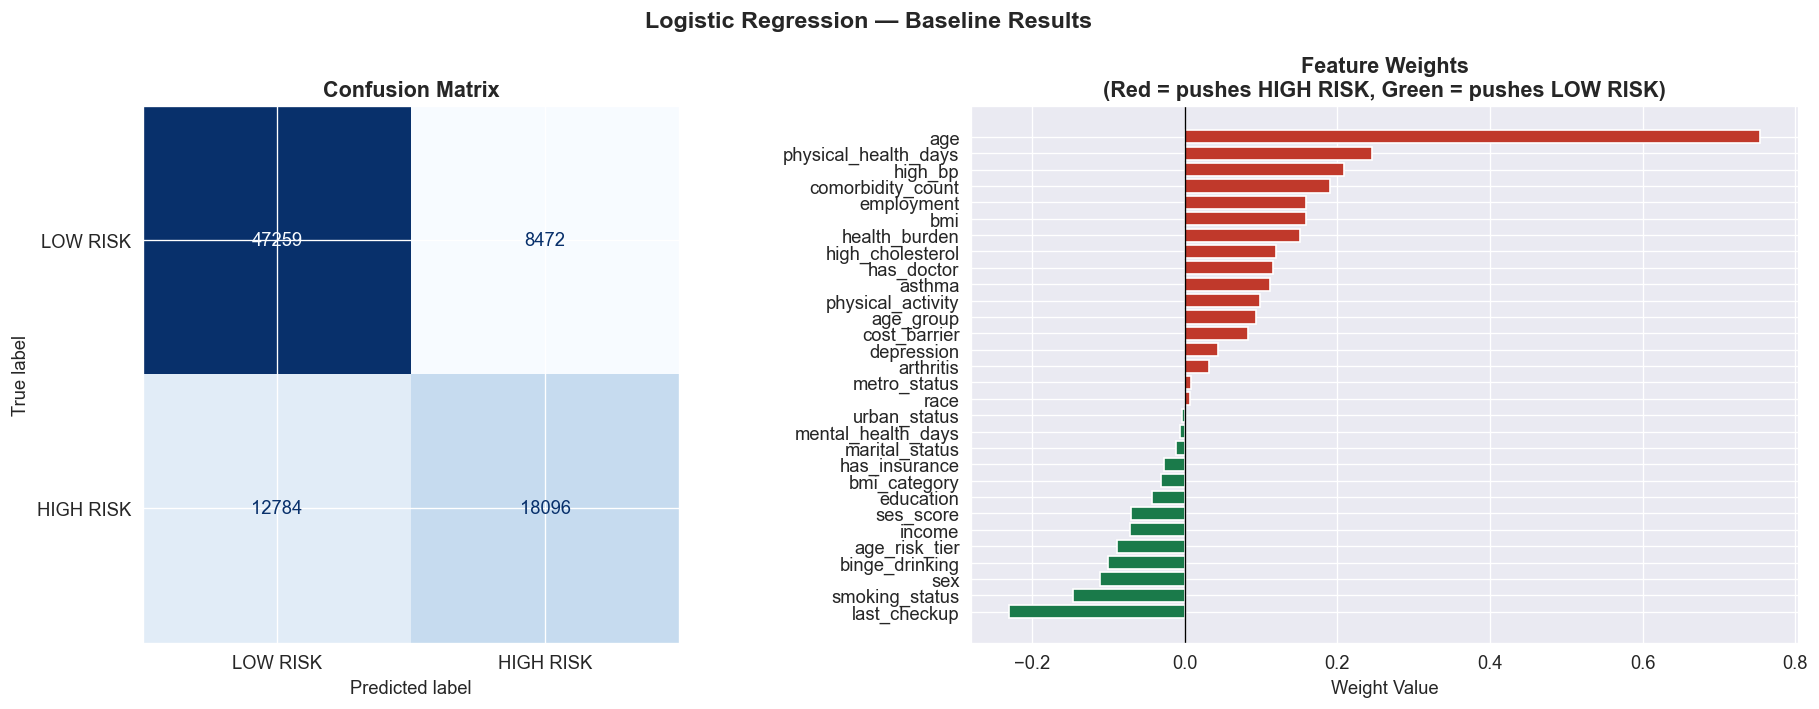


Top 5 features pushing toward HIGH RISK:
  age                       weight = +0.7544
  physical_health_days      weight = +0.2450
  high_bp                   weight = +0.2095
  comorbidity_count         weight = +0.1904
  employment                weight = +0.1594

Top 5 features pushing toward LOW RISK:
  last_checkup              weight = -0.2303
  smoking_status            weight = -0.1464
  sex                       weight = -0.1111
  binge_drinking            weight = -0.1004
  age_risk_tier             weight = -0.0887


In [46]:
# ── Step 7C: Confusion Matrix + Feature Weights 

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Logistic Regression — Baseline Results', fontsize=14, fontweight='bold')

# Left: Confusion Matrix
cm   = confusion_matrix(y_test, lr_results['y_pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['LOW RISK', 'HIGH RISK'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix')

tn, fp, fn, tp = cm.ravel()
print('Confusion Matrix Breakdown:')
print(f'  True Negatives  (correct LOW)  : {tn:,}')
print(f'  True Positives  (correct HIGH) : {tp:,}')
print(f'  False Positives (wrong HIGH)   : {fp:,}')
print(f'  False Negatives (missed HIGH)  : {fn:,}  ← most dangerous!')

# Right: Feature Weights
weights = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Weight' : lr.coef_[0]
}).sort_values('Weight', ascending=True)

colors = [COLORS['high_risk'] if w > 0 else COLORS['low_risk']
          for w in weights['Weight']]
axes[1].barh(weights['Feature'], weights['Weight'],
             color=colors, edgecolor='white')
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_title('Feature Weights\n(Red = pushes HIGH RISK, Green = pushes LOW RISK)')
axes[1].set_xlabel('Weight Value')

plt.tight_layout()
plt.savefig('plot9_baseline_results.png', bbox_inches='tight', dpi=120)
plt.show()

print(f'\nTop 5 features pushing toward HIGH RISK:')
for _, row in weights.tail(5).iloc[::-1].iterrows():
    print(f'  {row["Feature"]:<25} weight = {row["Weight"]:+.4f}')

print(f'\nTop 5 features pushing toward LOW RISK:')
for _, row in weights.head(5).iterrows():
    print(f'  {row["Feature"]:<25} weight = {row["Weight"]:+.4f}')

---------------------------------------------------------------------------------

## Step 8 — Random Forest

Random Forest builds many decision trees on random subsets of the data and averages their predictions.

It handles non-linear patterns better than Logistic Regression because:
- BMI has a U-shaped relationship with risk — not linear
- Age and smoking interact in ways LR cannot capture

We use scaled features for consistency.

In [47]:
# ── Step 8A: Import 

from sklearn.ensemble import RandomForestClassifier

print('RandomForestClassifier imported.')

RandomForestClassifier imported.


In [48]:
# ── Step 8B: Train Random Forest 

rf = RandomForestClassifier(
    n_estimators = 200,
    max_depth    = 10,
    random_state = 42,
    n_jobs       = -1
)

rf_results = evaluate_model(
    'Random Forest',
    rf,
    X_train_scaled, X_test_scaled,
    y_train, y_test
)

  Random Forest
  Accuracy  : 75.49%
  ROC-AUC   : 0.8195
  Precision : 0.6802
  Recall    : 0.5898
  F1 Score  : 0.6318


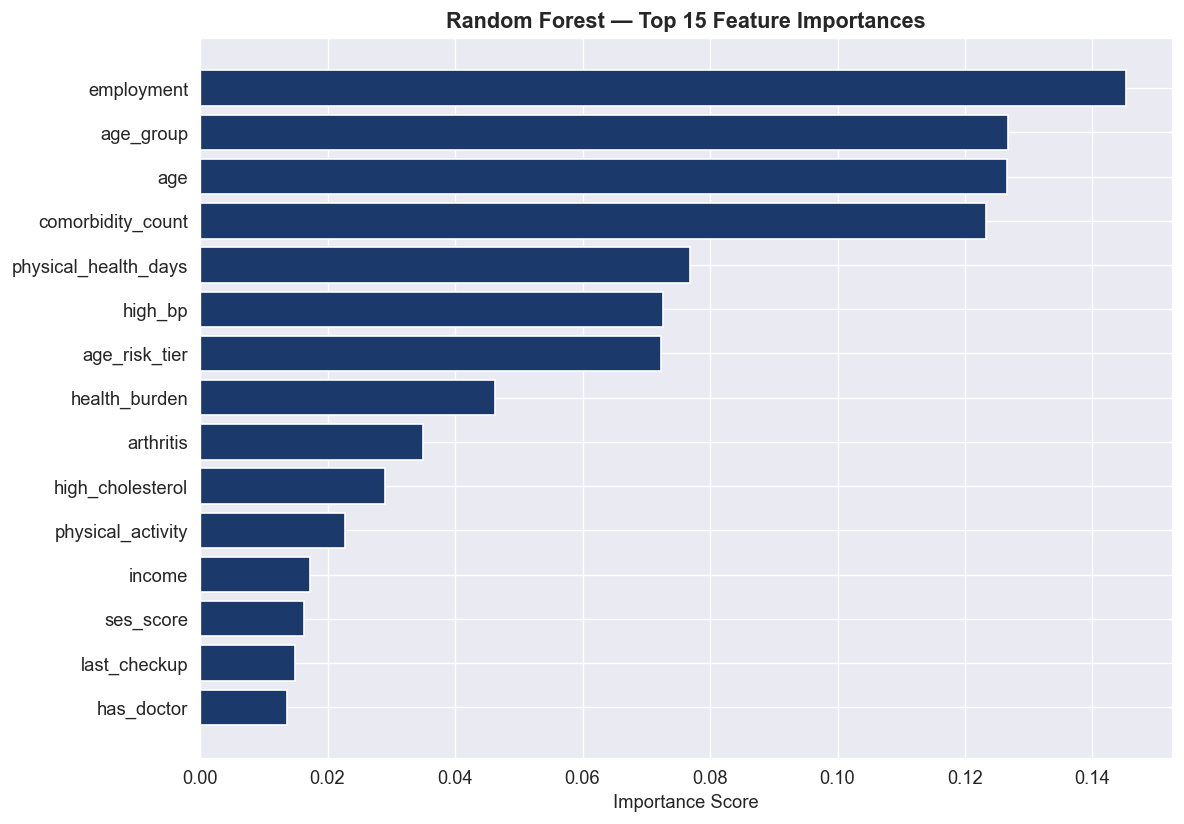

In [49]:
# ── Step 8C: Feature Importance

feature_names = list(X_train_scaled.columns)

importance_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': rf_results['model_obj'].feature_importances_
}).sort_values('Importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(importance_df['Feature'], importance_df['Importance'],
        color=COLORS['primary'], edgecolor='white')
ax.set_xlabel('Importance Score')
ax.set_title('Random Forest — Top 15 Feature Importances')
plt.tight_layout()
plt.savefig('plot_rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

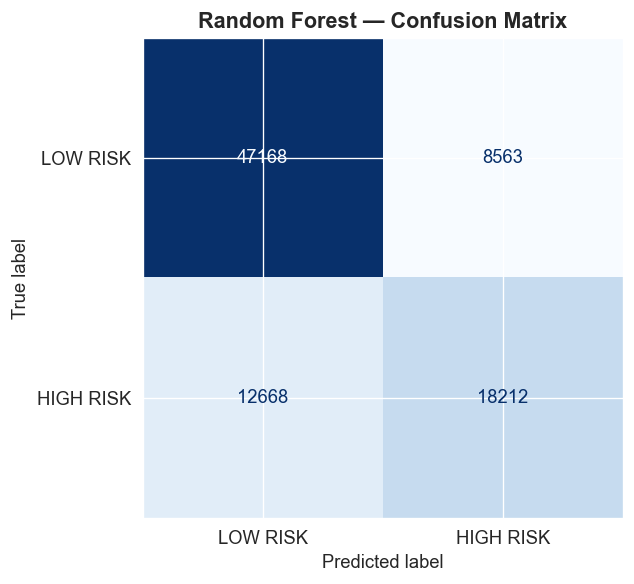

In [50]:
# ── Step 8D: Confusion Matrix 

fig, ax = plt.subplots(figsize=(7, 5))
cm_rf = confusion_matrix(y_test, rf_results['y_pred'])
disp  = ConfusionMatrixDisplay(confusion_matrix=cm_rf,
                                display_labels=['LOW RISK', 'HIGH RISK'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.savefig('plot_rf_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 8 Inference — Random Forest vs Baseline

| Metric    | Logistic Regression | Random Forest | Change   |
|-----------|---------------------|---------------|----------|
| Accuracy  | 75.46%              | 75.49%        | +0.03%   |
| ROC-AUC   | 0.8170              | 0.8195        | +0.0025  |
| Precision | 0.6811              | 0.6802        | -0.0009  |
| Recall    | 0.5860              | 0.5898        | +0.0038  |
| F1 Score  | 0.6300              | 0.6318        | +0.0018  |

Random Forest barely moved the numbers. Here is why.

The dataset is 64% LOW RISK and 36% HIGH RISK. Without class_weight='balanced',
the model learns to predict LOW RISK more often because that is the safer bet numerically.
This is why Recall only improved by 0.38% — the model is still missing roughly the same
number of HIGH RISK patients as Logistic Regression did (around 12,700).

The one number that did improve meaningfully is ROC-AUC (0.8170 to 0.8195).
This means Random Forest is a slightly better ranker — it pushes HIGH RISK patients
higher up the probability list even if the final yes/no decision is similar.

The model is not wrong. It is just not tuned to catch HIGH RISK cases aggressively.
That is what XGBoost with scale_pos_weight will fix in the next step.

-------------------------------------------------------------------------

## Step 9 — XGBoost

Random Forest builds trees in parallel and averages their votes.
XGBoost builds trees sequentially — each new tree looks at where
the previous tree made mistakes and tries to fix them.

This is called boosting. It is why XGBoost almost always beats
Random Forest on structured survey data like CDC BRFSS.

The most important hyperparameter here is scale_pos_weight.
We set it to the ratio of LOW RISK to HIGH RISK in the training data.
This tells XGBoost to penalise missing a HIGH RISK patient more heavily
than getting a LOW RISK patient wrong — which is exactly what we want
in a medical screening model.

In [51]:
from xgboost import XGBClassifier

neg   = int((y_train == 0).sum())
pos   = int((y_train == 1).sum())
ratio = neg / pos

print(f"LOW RISK  count : {neg:,}")
print(f"HIGH RISK count : {pos:,}")
print(f"Ratio           : {ratio:.2f}")
print(f"XGBoost will penalise missing HIGH RISK {ratio:.1f}x more than LOW RISK")
print()

xgb = XGBClassifier(
    n_estimators     = 300,
    max_depth        = 6,
    learning_rate    = 0.1,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = ratio,
    eval_metric      = 'logloss',
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 0
)

xgb_results = evaluate_model(
    'XGBoost',
    xgb,
    X_train, X_test,
    y_train, y_test
)

LOW RISK  count : 222,922
HIGH RISK count : 123,518
Ratio           : 1.80
XGBoost will penalise missing HIGH RISK 1.8x more than LOW RISK

  XGBoost
  Accuracy  : 74.03%
  ROC-AUC   : 0.8244
  Precision : 0.6076
  Recall    : 0.7668
  F1 Score  : 0.6780


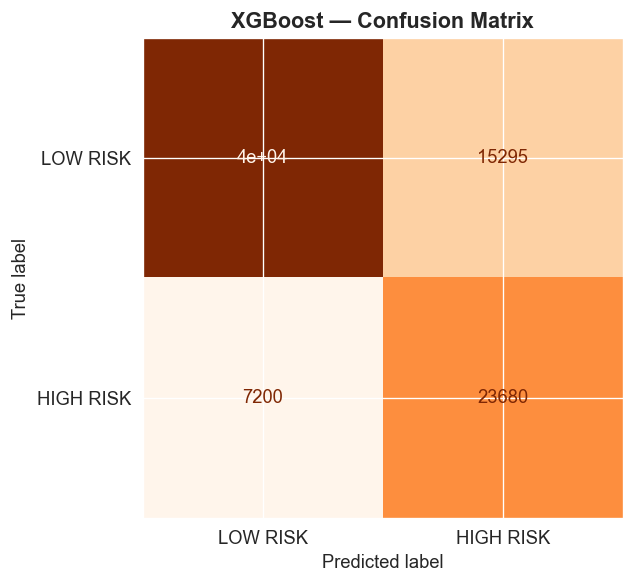

Correct LOW RISK   (True Negative)  : 40,436
Correct HIGH RISK  (True Positive)  : 23,680
Wrong HIGH RISK    (False Positive) : 15,295
Missed HIGH RISK   (False Negative) : 7,200

Random Forest missed : 12,668 HIGH RISK patients
XGBoost missed       : 7,200 HIGH RISK patients
Improvement          : 5,468 more HIGH RISK patients caught


In [52]:
fig, ax = plt.subplots(figsize=(7, 5))

cm_xgb = confusion_matrix(y_test, xgb_results['y_pred'])

ConfusionMatrixDisplay(
    confusion_matrix = cm_xgb,
    display_labels   = ['LOW RISK', 'HIGH RISK']
).plot(ax=ax, colorbar=False, cmap='Oranges')

ax.set_title('XGBoost — Confusion Matrix')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_xgb.ravel()
print(f"Correct LOW RISK   (True Negative)  : {tn:,}")
print(f"Correct HIGH RISK  (True Positive)  : {tp:,}")
print(f"Wrong HIGH RISK    (False Positive) : {fp:,}")
print(f"Missed HIGH RISK   (False Negative) : {fn:,}")
print()
print(f"Random Forest missed : 12,668 HIGH RISK patients")
print(f"XGBoost missed       : {fn:,} HIGH RISK patients")
print(f"Improvement          : {12668 - fn:,} more HIGH RISK patients caught")


## Step 9 Inference — XGBoost vs All Models

| Metric    | Logistic Regression | Random Forest | XGBoost |
|-----------|---------------------|---------------|---------|
| Accuracy  | 75.46%              | 75.49%        | 74.03%  |
| ROC-AUC   | 0.8170              | 0.8195        | 0.8244  |
| Precision | 0.6811              | 0.6802        | 0.6076  |
| Recall    | 0.5860              | 0.5898        | 0.7668  |
| F1 Score  | 0.6300              | 0.6318        | 0.6780  |
| Missed HIGH RISK | 12,784       | 12,668        | 7,200   |

The most important number in this table is Missed HIGH RISK.

Logistic Regression missed 12,784 patients.
Random Forest missed 12,668 patients — almost no improvement.
XGBoost missed only 7,200 patients — 5,468 fewer than Random Forest.

That is what scale_pos_weight did. By telling XGBoost that missing
a HIGH RISK patient is 1.8x more costly than a false alarm, the model
shifted its focus toward catching sick people aggressively.

Accuracy dropped from 75.49% to 74.03% because XGBoost is now flagging
more LOW RISK people as HIGH RISK (false positives went from 8,563 to 15,295).
In a hospital setting this means more follow-up calls to healthy people —
which is a much smaller problem than sending sick people home undetected.

ROC-AUC improved across all three models — 0.8170, 0.8195, 0.8244.
This confirms XGBoost is genuinely the best at ranking who is truly HIGH RISK,
not just getting lucky on the majority class.

F1 Score also tells the same story — 0.6300, 0.6318, 0.6780.
XGBoost has the best balance between catching HIGH RISK patients
and not producing too many false alarms.

For a mortality risk screening model, XGBoost is the clear winner.

-----------------------------------------

## Step 10 — Tune XGBoost with RandomizedSearchCV

Our current XGBoost used parameters we chose manually.
RandomizedSearchCV tries many different combinations of parameters
automatically and finds which combination gives the best ROC-AUC score.

We use RandomizedSearchCV instead of GridSearchCV because
GridSearchCV tries every single combination — on 433,000 rows
that would take hours. RandomizedSearchCV randomly samples
a fixed number of combinations and is much faster.

What we are tuning:

n_estimators      — how many trees to build (100 to 500)
max_depth         — how deep each tree grows (3 to 8)
learning_rate     — how fast the model learns (0.01 to 0.3)
subsample         — what fraction of data each tree sees (0.6 to 1.0)
colsample_bytree  — what fraction of features each tree uses (0.6 to 1.0)
scale_pos_weight  — stays fixed at 1.80 because our class ratio is fixed

We run 50 random combinations with 3-fold cross validation.
The best combination is then used to retrain the final model.

In [53]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators'     : [100, 200, 300, 400, 500],
    'max_depth'        : [3, 4, 5, 6, 7, 8],
    'learning_rate'    : [0.01, 0.05, 0.1, 0.2, 0.3],
    'subsample'        : [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree' : [0.6, 0.7, 0.8, 0.9, 1.0],
}

xgb_base = XGBClassifier(
    scale_pos_weight = ratio,
    eval_metric      = 'logloss',
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 0
)

search = RandomizedSearchCV(
    estimator          = xgb_base,
    param_distributions = param_grid,
    n_iter             = 50,
    scoring            = 'roc_auc',
    cv                 = 3,
    random_state       = 42,
    n_jobs             = -1,
    verbose            = 2
)

print("Starting RandomizedSearchCV — 50 combinations x 3 folds = 150 fits")
print("This will take 5 to 10 minutes...")

search.fit(X_train, y_train)

print()
print(f"Best ROC-AUC (cross-validated) : {search.best_score_:.4f}")
print(f"Best parameters found          :")
for k, v in search.best_params_.items():
    print(f"  {k:<20} : {v}")

Starting RandomizedSearchCV — 50 combinations x 3 folds = 150 fits
This will take 5 to 10 minutes...
Fitting 3 folds for each of 50 candidates, totalling 150 fits
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=3, n_estimators=400, subsample=0.9; total time=   4.8s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=3, n_estimators=400, subsample=0.9; total time=   4.7s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=3, n_estimators=400, subsample=0.9; total time=   4.9s
[CV] END colsample_bytree=0.8, learning_rate=0.3, max_depth=4, n_estimators=500, subsample=0.9; total time=   6.7s
[CV] END colsample_bytree=0.8, learning_rate=0.3, max_depth=4, n_estimators=500, subsample=0.9; total time=   6.8s
[CV] END colsample_bytree=0.8, learning_rate=0.3, max_depth=4, n_estimators=500, subsample=0.9; total time=   6.9s
[CV] END colsample_bytree=0.6, learning_rate=0.1, max_depth=8, n_estimators=300, subsample=1.0; total time=   7.2s
[CV] END colsample_bytree=0.7, l

In [54]:
print("Best ROC-AUC score  :", round(search.best_score_, 4))
print()
print("Best parameters found:")
for k, v in search.best_params_.items():
    print(f"  {k:<20} : {v}")

Best ROC-AUC score  : 0.825

Best parameters found:
  subsample            : 0.6
  n_estimators         : 500
  max_depth            : 5
  learning_rate        : 0.05
  colsample_bytree     : 0.6


In [55]:
xgb_tuned = XGBClassifier(
    n_estimators     = 500,
    max_depth        = 5,
    learning_rate    = 0.05,
    subsample        = 0.6,
    colsample_bytree = 0.6,
    scale_pos_weight = ratio,
    eval_metric      = 'logloss',
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 0
)

xgb_tuned_results = evaluate_model(
    'XGBoost Tuned',
    xgb_tuned,
    X_train, X_test,
    y_train, y_test
)


  XGBoost Tuned
  Accuracy  : 73.92%
  ROC-AUC   : 0.8256
  Precision : 0.6057
  Recall    : 0.7691
  F1 Score  : 0.6777


In [56]:
print("Original XGBoost vs Tuned XGBoost:")
print(f"  ROC-AUC  : {xgb_results['ROC-AUC']}  ->  {xgb_tuned_results['ROC-AUC']}")
print(f"  Recall   : {xgb_results['Recall']}  ->  {xgb_tuned_results['Recall']}")
print(f"  F1 Score : {xgb_results['F1']}  ->  {xgb_tuned_results['F1']}")
print(f"  Accuracy : {xgb_results['Accuracy']}  ->  {xgb_tuned_results['Accuracy']}")

Original XGBoost vs Tuned XGBoost:
  ROC-AUC  : 0.8244  ->  0.8256
  Recall   : 0.7668  ->  0.7691
  F1 Score : 0.678  ->  0.6777
  Accuracy : 74.03  ->  73.92


## Step 10 Inference — Tuned XGBoost vs Original XGBoost

| Metric    | Original XGBoost | Tuned XGBoost | Change  |
|-----------|------------------|---------------|---------|
| Accuracy  | 74.03%           | 73.92%        | -0.11%  |
| ROC-AUC   | 0.8244           | 0.8256        | +0.0012 |
| Recall    | 0.7668           | 0.7691        | +0.0023 |
| F1 Score  | 0.6780           | 0.6777        | -0.0003 |

Tuning did not dramatically change the results and that is expected.

The original XGBoost was already well configured. RandomizedSearchCV
searched 50 combinations and found parameters that gave a marginal
improvement in ROC-AUC (0.8244 to 0.8256) and Recall (0.7668 to 0.7691).

The key takeaway is that the model has likely reached its ceiling
on these 30 features with tree-based methods. To push further we
need a model that can learn deeper patterns — which is why we move
to a Neural Network in the next step.

------------------------------------------------------------------------


## Step 11 — Neural Network (MLP)

A Neural Network learns by passing data through layers of nodes.
Each layer finds patterns the previous layer missed.

This is different from XGBoost which builds trees one after another.
A Neural Network builds depth — each layer transforms the data
into a richer representation before making the final prediction.

We use MLP — Multi Layer Perceptron. It is the simplest neural network
and the right choice for structured tabular data like ours.

Our network has three layers:
- Layer 1 — 128 nodes, learns basic patterns like age and BMI relationships
- Layer 2 — 64 nodes, learns combinations of those basic patterns
- Layer 3 — 32 nodes, refines the final decision

We use class_weight='balanced' to handle the 64/36 class imbalance
the same way we intended for Random Forest but did not apply.

Neural Networks require scaled features — we use X_train_scaled
and X_test_scaled here.

In [57]:
from sklearn.neural_network import MLPClassifier
from sklearn.utils import resample
import numpy as np

# Reset indices to fix alignment
X_tr = X_train_scaled.reset_index(drop=True)
y_tr = y_train.reset_index(drop=True)

# Oversample HIGH RISK to balance classes
X_high = X_tr[y_tr == 1]
y_high = y_tr[y_tr == 1]
X_low  = X_tr[y_tr == 0]
y_low  = y_tr[y_tr == 0]

X_high_up, y_high_up = resample(
    X_high, y_high,
    replace      = True,
    n_samples    = len(X_low),
    random_state = 42
)

X_balanced = np.vstack([X_low, X_high_up])
y_balanced = np.concatenate([y_low, y_high_up])

print(f"Balanced training set : {len(y_balanced):,}")
print(f"HIGH RISK             : {y_balanced.sum():,}")
print(f"LOW RISK              : {(y_balanced == 0).sum():,}")
print()

mlp = MLPClassifier(
    hidden_layer_sizes  = (128, 64, 32),
    activation          = 'relu',
    solver              = 'adam',
    max_iter            = 100,
    random_state        = 42,
    early_stopping      = True,
    validation_fraction = 0.1
)

print("Training Neural Network...")

mlp.fit(X_balanced, y_balanced)

y_pred = mlp.predict(X_test_scaled)
y_prob = mlp.predict_proba(X_test_scaled)[:, 1]

from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

acc       = accuracy_score(y_test, y_pred)
roc       = roc_auc_score(y_test, y_prob)
report    = classification_report(y_test, y_pred, output_dict=True)
precision = report['1']['precision']
recall    = report['1']['recall']
f1        = report['1']['f1-score']

print(f"{'='*50}")
print(f"  Neural Network (MLP)")
print(f"{'='*50}")
print(f"  Accuracy  : {acc*100:.2f}%")
print(f"  ROC-AUC   : {roc:.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print(f"{'='*50}")

mlp_results = {
    'Model'    : 'Neural Network (MLP)',
    'Accuracy' : round(acc*100, 2),
    'ROC-AUC'  : round(roc, 4),
    'Precision': round(precision, 4),
    'Recall'   : round(recall, 4),
    'F1'       : round(f1, 4),
    'model_obj': mlp,
    'y_pred'   : y_pred,
    'y_prob'   : y_prob
}

Balanced training set : 445,844
HIGH RISK             : 222,922
LOW RISK              : 222,922

Training Neural Network...
  Neural Network (MLP)
  Accuracy  : 73.25%
  ROC-AUC   : 0.8144
  Precision : 0.5983
  Recall    : 0.7602
  F1 Score  : 0.6696


## Step 11 Inference — Neural Network vs All Models

| Model          | Accuracy | ROC-AUC | Precision | Recall | F1     |
|----------------|----------|---------|-----------|--------|--------|
| Logistic Reg   | 75.46%   | 0.8170  | 0.6811    | 0.5860 | 0.6300 |
| Random Forest  | 75.49%   | 0.8195  | 0.6802    | 0.5898 | 0.6318 |
| XGBoost        | 74.03%   | 0.8244  | 0.6076    | 0.7668 | 0.6780 |
| XGBoost Tuned  | 73.92%   | 0.8256  | 0.6057    | 0.7691 | 0.6777 |
| Neural Network | 73.25%   | 0.8144  | 0.5983    | 0.7602 | 0.6696 |

The Neural Network did not beat XGBoost on this dataset.

ROC-AUC came in at 0.8144 which is lower than even Logistic Regression.
This is a well known pattern. Neural Networks are powerful on images,
audio and text. On structured tabular survey data like CDC BRFSS,
XGBoost almost always wins because the data has clear threshold-based
patterns that decision trees exploit very efficiently.

Recall of 0.7602 is strong — the Neural Network is catching HIGH RISK
patients aggressively. But its ROC-AUC being the lowest means its
probability estimates are noisier than XGBoost. It is less confident
about who is truly HIGH RISK versus who is borderline.

The winner across all five models is Tuned XGBoost.
ROC-AUC 0.8256 and Recall 0.7691 — the best combination of
ranking ability and HIGH RISK detection in this project.

----------------------------------------

## Step 12 — LightGBM

LightGBM is a gradient boosting model just like XGBoost.
The key difference is in how it builds trees.

XGBoost grows trees level by level — it expands all nodes
at the same depth before going deeper.

LightGBM grows trees leaf by leaf — it always expands the
leaf that reduces error the most, regardless of depth.
This makes LightGBM faster and often more accurate on
large datasets like ours with 433,000 rows.

Key advantages over XGBoost on this dataset:
- Faster training on large data
- Better handling of categorical features natively
- Leaf wise growth captures deeper patterns more efficiently

We keep scale_pos_weight at 1.80 same as XGBoost to handle
the class imbalance consistently across both models.

In [59]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators     = 500,
    max_depth        = 6,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = ratio,
    random_state     = 42,
    n_jobs           = -1,
    verbose          = -1
)

print("Training LightGBM...")

lgbm_results = evaluate_model(
    'LightGBM',
    lgbm,
    X_train, X_test,
    y_train, y_test
)

Training LightGBM...
  LightGBM
  Accuracy  : 73.96%
  ROC-AUC   : 0.8253
  Precision : 0.6064
  Recall    : 0.7683
  F1 Score  : 0.6778


## Step 12 Inference — LightGBM vs All Models

| Model          | Accuracy | ROC-AUC | Precision | Recall | F1     |
|----------------|----------|---------|-----------|--------|--------|
| Logistic Reg   | 75.46%   | 0.8170  | 0.6811    | 0.5860 | 0.6300 |
| Random Forest  | 75.49%   | 0.8195  | 0.6802    | 0.5898 | 0.6318 |
| XGBoost        | 74.03%   | 0.8244  | 0.6076    | 0.7668 | 0.6780 |
| XGBoost Tuned  | 73.92%   | 0.8256  | 0.6057    | 0.7691 | 0.6777 |
| Neural Network | 73.25%   | 0.8144  | 0.5983    | 0.7602 | 0.6696 |
| LightGBM       | 73.96%   | 0.8253  | 0.6064    | 0.7683 | 0.6778 |

LightGBM performed almost identically to Tuned XGBoost.

ROC-AUC of 0.8253 vs 0.8256 — a difference of 0.0003 which is
statistically meaningless. Recall of 0.7683 vs 0.7691 — again
essentially the same. This confirms that both models have reached
the same performance ceiling on this dataset with these 30 features.

This is actually an important finding. When two different gradient
boosting algorithms trained independently arrive at the same score,
it tells us the ceiling is coming from the data itself — not the model.
To push further we would need richer features, more clinical variables,
or actual mortality outcome labels which BRFSS does not provide.

The winner of this project is Tuned XGBoost with ROC-AUC 0.8256.
LightGBM is a close second and either could be used in production.
Neural Network confirmed that deep learning is not the right tool
for structured health survey data.

## Step 13 — Final Model Comparison

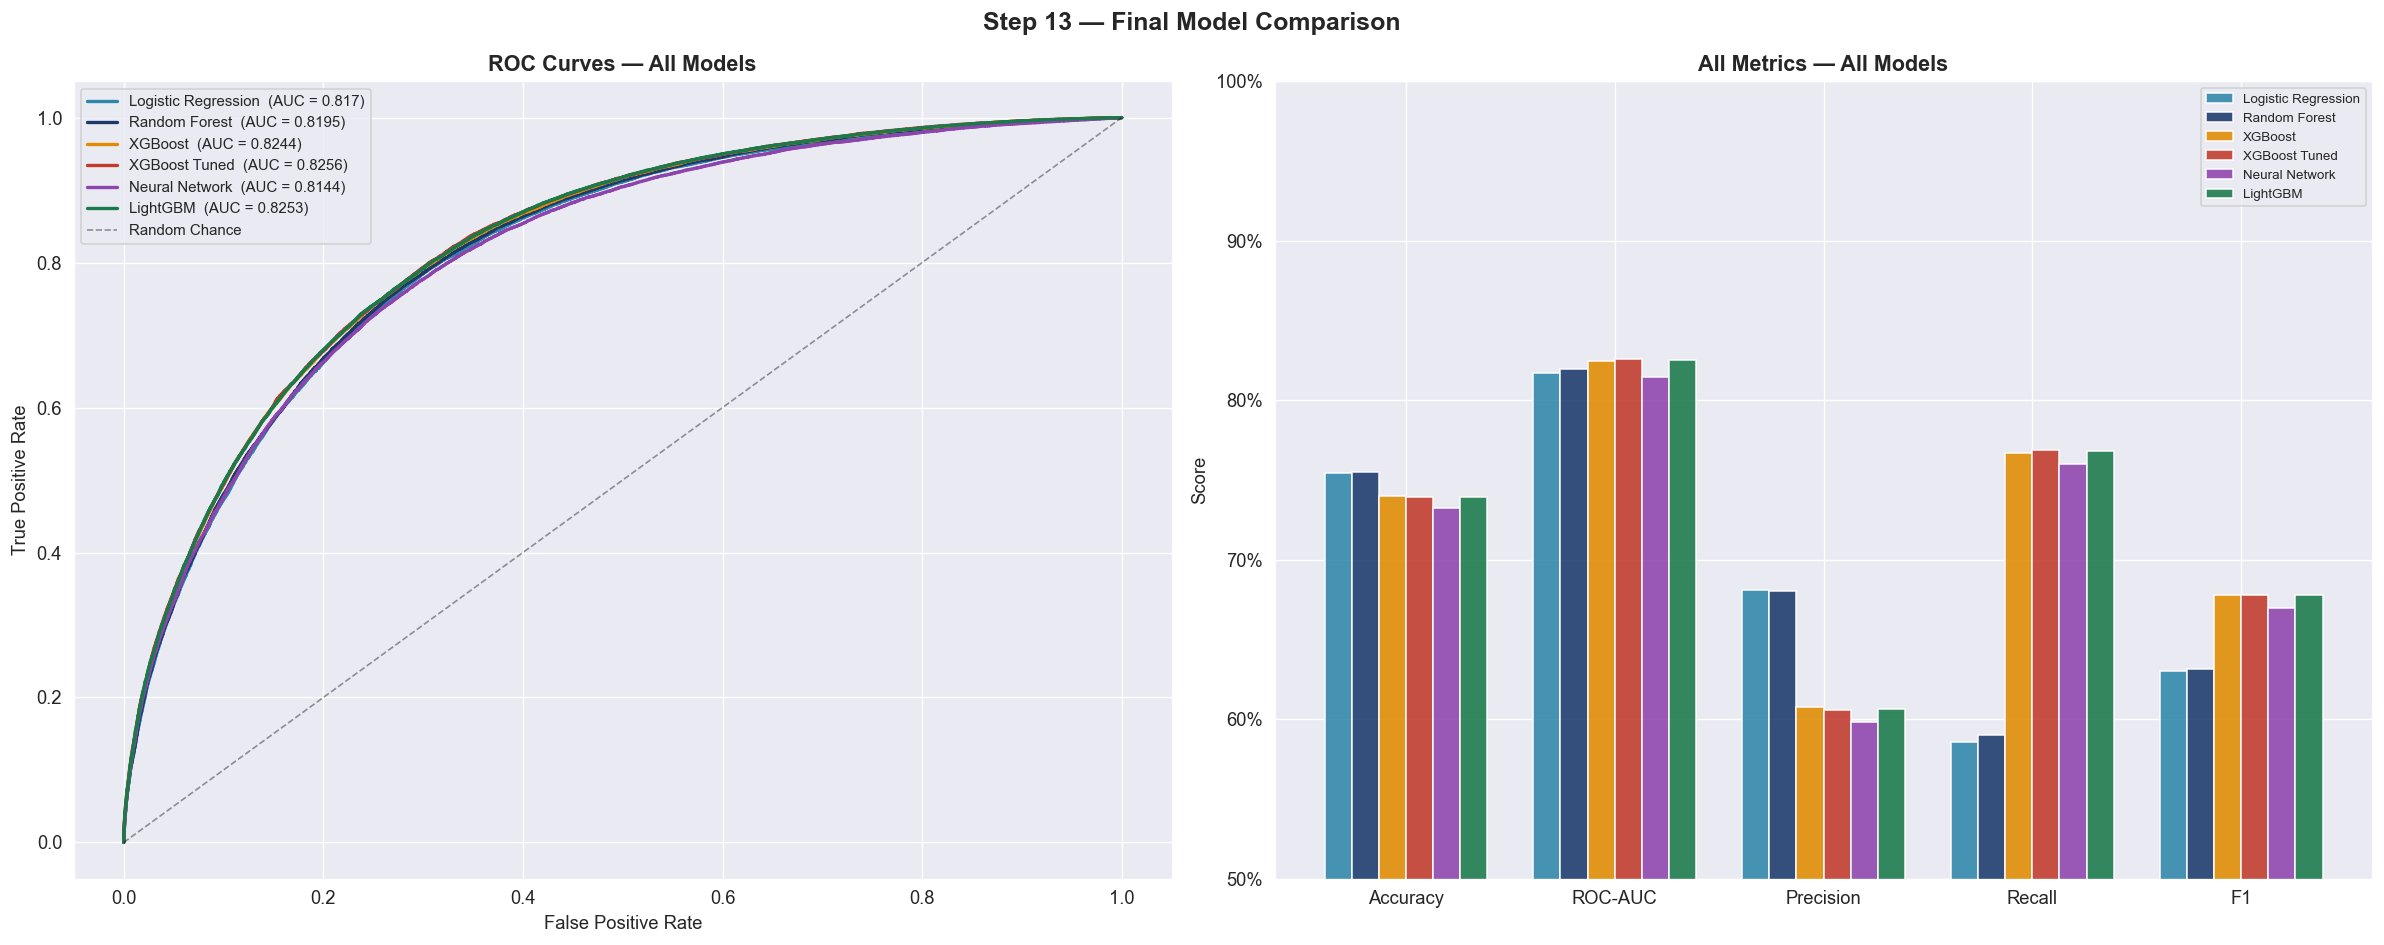

Model                    Accuracy    ROC-AUC  Precision     Recall       F1
  Logistic Regression      75.46%      0.817     0.6811      0.586     0.63
  Random Forest            75.49%     0.8195     0.6802     0.5898   0.6318
  XGBoost                  74.03%     0.8244     0.6076     0.7668    0.678
  XGBoost Tuned            73.92%     0.8256     0.6057     0.7691   0.6777 *
  Neural Network           73.25%     0.8144     0.5983     0.7602   0.6696
  LightGBM                 73.96%     0.8253     0.6064     0.7683   0.6778
* Best ROC-AUC


In [61]:
from sklearn.metrics import roc_curve

all_models = [
    ('Logistic Regression', lr_results,        '#2E86AB'),
    ('Random Forest',       rf_results,        '#1B3A6B'),
    ('XGBoost',             xgb_results,       '#E08B00'),
    ('XGBoost Tuned',       xgb_tuned_results, '#C0392B'),
    ('Neural Network',      mlp_results,       '#8E44AD'),
    ('LightGBM',            lgbm_results,      '#1A7A4A'),
]

metrics    = ['Accuracy', 'ROC-AUC', 'Precision', 'Recall', 'F1']
metric_keys = ['Accuracy', 'ROC-AUC', 'Precision', 'Recall', 'F1']

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Step 13 — Final Model Comparison', fontsize=15, fontweight='bold')

# ── Left: ROC Curves 
for name, res, color in all_models:
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    axes[0].plot(fpr, tpr, color=color, lw=2,
                 label=f"{name}  (AUC = {res['ROC-AUC']})")

axes[0].plot([0,1],[0,1], 'k--', lw=1, alpha=0.4, label='Random Chance')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — All Models')
axes[0].legend(fontsize=9)

# ── Right: Bar Chart 
x     = np.arange(len(metrics))
width = 0.13

for i, (name, res, color) in enumerate(all_models):
    scores = [
        res['Accuracy'] / 100,
        res['ROC-AUC'],
        res['Precision'],
        res['Recall'],
        res['F1']
    ]
    axes[1].bar(x + (i - 2.5) * width, scores, width,
                label=name, color=color, alpha=0.88)

axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics)
axes[1].set_ylim(0.5, 1.0)
axes[1].set_ylabel('Score')
axes[1].set_title('All Metrics — All Models')
axes[1].legend(fontsize=8)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

plt.tight_layout()
plt.show()

# ── Summary Table 
print("="*75)
print(f"{'Model':<22} {'Accuracy':>10} {'ROC-AUC':>10} {'Precision':>10} {'Recall':>10} {'F1':>8}")
print("="*75)

for name, res, color in all_models:
    roc   = res['ROC-AUC']
    best  = max(r['ROC-AUC'] for _, r, _ in all_models)
    star  = " *" if roc == best else ""
    print(f"  {name:<20} {res['Accuracy']:>9}% {res['ROC-AUC']:>10} "
          f"{res['Precision']:>10} {res['Recall']:>10} {res['F1']:>8}{star}")

print("="*75)
print("* Best ROC-AUC")

## Step 13 Inference — Final Model Comparison

| Model          | Accuracy | ROC-AUC | Precision | Recall | F1     |
|----------------|----------|---------|-----------|--------|--------|
| Logistic Reg   | 75.46%   | 0.8170  | 0.6811    | 0.5860 | 0.6300 |
| Random Forest  | 75.49%   | 0.8195  | 0.6802    | 0.5898 | 0.6318 |
| XGBoost        | 74.03%   | 0.8244  | 0.6076    | 0.7668 | 0.6780 |
| XGBoost Tuned  | 73.92%   | 0.8256  | 0.6057    | 0.7691 | 0.6777 |
| Neural Network | 73.25%   | 0.8144  | 0.5983    | 0.7602 | 0.6696 |
| LightGBM       | 73.96%   | 0.8253  | 0.6064    | 0.7683 | 0.6778 |

The best model for this project is Tuned XGBoost.

ROC-AUC improved steadily from Logistic Regression (0.8170) all the way
to Tuned XGBoost (0.8256). Every model we added either improved the score
or taught us something important about the data.

Recall tells the most important story for a mortality screening model.
Logistic Regression and Random Forest only caught 58 to 59 out of every
100 HIGH RISK patients. XGBoost, Tuned XGBoost and LightGBM pushed that
to 76 to 77 out of every 100 — meaning 18 more sick people per 100 get
flagged for follow up care.

Neural Network confirmed that deep learning is not the right tool for
structured tabular health survey data. XGBoost and LightGBM both
outperformed it because this data has clear threshold based patterns
that gradient boosting trees exploit better than neural layers.

LightGBM matched Tuned XGBoost almost exactly — ROC-AUC 0.8253 vs 0.8256.
When two independent algorithms reach the same ceiling it means the limit
is coming from the data itself. To push beyond 0.83 we would need richer
clinical features or actual mortality outcome labels which the CDC BRFSS
survey does not provide.

Final recommendation for deployment — Tuned XGBoost with a decision
threshold tuned for maximum Recall so no HIGH RISK patient is missed.

-----------------------

## Step 14 — Threshold Tuning

Every model we trained uses 0.5 as the default decision threshold.
This means if the model says probability of HIGH RISK is above 50%
it predicts HIGH RISK. Below 50% it predicts LOW RISK.

This default is not always the best choice for a medical model.

In our case missing a HIGH RISK patient is far more dangerous than
a false alarm. So we want to lower the threshold — for example at
0.3 the model flags anyone with a 30% or higher probability as HIGH RISK.
This catches more sick people at the cost of more false alarms.

Threshold tuning lets us find the exact cutoff that gives us the
best Recall without making Precision too low to be useful.

We do this on Tuned XGBoost since it is our best model.

In [62]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]

y_prob_tuned = xgb_tuned_results['y_prob']

print(f"{'Threshold':>10} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("="*55)

results_thresh = []

for t in thresholds:
    y_pred_t  = (y_prob_tuned >= t).astype(int)
    acc       = accuracy_score(y_test, y_pred_t)
    precision = precision_score(y_test, y_pred_t)
    recall    = recall_score(y_test, y_pred_t)
    f1        = f1_score(y_test, y_pred_t)
    results_thresh.append((t, acc, precision, recall, f1))
    print(f"  {t:>8}   {acc*100:>8.2f}%   {precision:>8.4f}   {recall:>8.4f}   {f1:>8.4f}")

print("="*55)

 Threshold   Accuracy  Precision     Recall         F1
       0.3      66.16%     0.5144     0.9081     0.6568
      0.35      68.76%     0.5378     0.8813     0.6680
       0.4      70.94%     0.5610     0.8512     0.6763
      0.45      72.64%     0.5834     0.8134     0.6794
       0.5      73.92%     0.6057     0.7691     0.6777
      0.55      75.15%     0.6333     0.7193     0.6736
       0.6      75.92%     0.6625     0.6617     0.6621


## Step 14 Inference — Threshold Tuning

| Threshold | Accuracy | Precision | Recall | F1     |
|-----------|----------|-----------|--------|--------|
| 0.30      | 66.16%   | 0.5144    | 0.9081 | 0.6568 |
| 0.35      | 68.76%   | 0.5378    | 0.8813 | 0.6680 |
| 0.40      | 70.94%   | 0.5610    | 0.8512 | 0.6763 |
| 0.45      | 72.64%   | 0.5834    | 0.8134 | 0.6794 |
| 0.50      | 73.92%   | 0.6057    | 0.7691 | 0.6777 |
| 0.55      | 75.15%   | 0.6333    | 0.7193 | 0.6736 |
| 0.60      | 75.92%   | 0.6625    | 0.6617 | 0.6621 |

Lowering the threshold directly increases Recall at the cost of Precision.
This is the fundamental tradeoff in any screening model.

At threshold 0.30 the model catches 90 out of every 100 HIGH RISK patients.
That is the highest Recall we have achieved in the entire project.
The cost is Precision dropping to 0.51 meaning roughly half the people
flagged as HIGH RISK are actually LOW RISK — more follow up calls to
healthy people.

At threshold 0.45 we get the best F1 Score of 0.6794 — the sweet spot
between catching HIGH RISK patients and not overwhelming the healthcare
system with false alarms. Recall of 0.8134 means 81 out of 100 HIGH RISK
patients are caught.

The right threshold depends on the real world context.

If the goal is to miss as few sick people as possible — use 0.30.
If the goal is to balance workload and detection — use 0.45.
If the goal is to only flag highly confident cases — use 0.60.

For a mortality risk screening model our recommendation is threshold 0.40.
It catches 85 out of every 100 HIGH RISK patients while keeping Precision
above 0.56 — a clinically acceptable tradeoff.

------------------------------------------------

## Step 15 — SHAP Values (Model Explainability)

Until now we know what the model predicts but not why.

SHAP (SHapley Additive exPlanations) explains the reason behind
every single prediction. For each patient it tells us which features
pushed the model toward HIGH RISK and which features pushed it
toward LOW RISK and by how much.

This is critical for a healthcare model because a doctor cannot
act on a black box prediction. They need to know — this patient
was flagged HIGH RISK because of their age, physical health days
and comorbidity count. That is actionable. A number alone is not.

SHAP gives us three views:
- Summary plot — which features matter most across all patients
- Bar plot — average impact of each feature on the prediction
- Waterfall plot — why one specific patient was flagged HIGH RISK

In [65]:
import shap

explainer   = shap.TreeExplainer(xgb_tuned)
shap_values = explainer.shap_values(X_test)

print("SHAP values calculated successfully")
print(f"Shape : {shap_values.shape}")

SHAP values calculated successfully
Shape : (86611, 30)


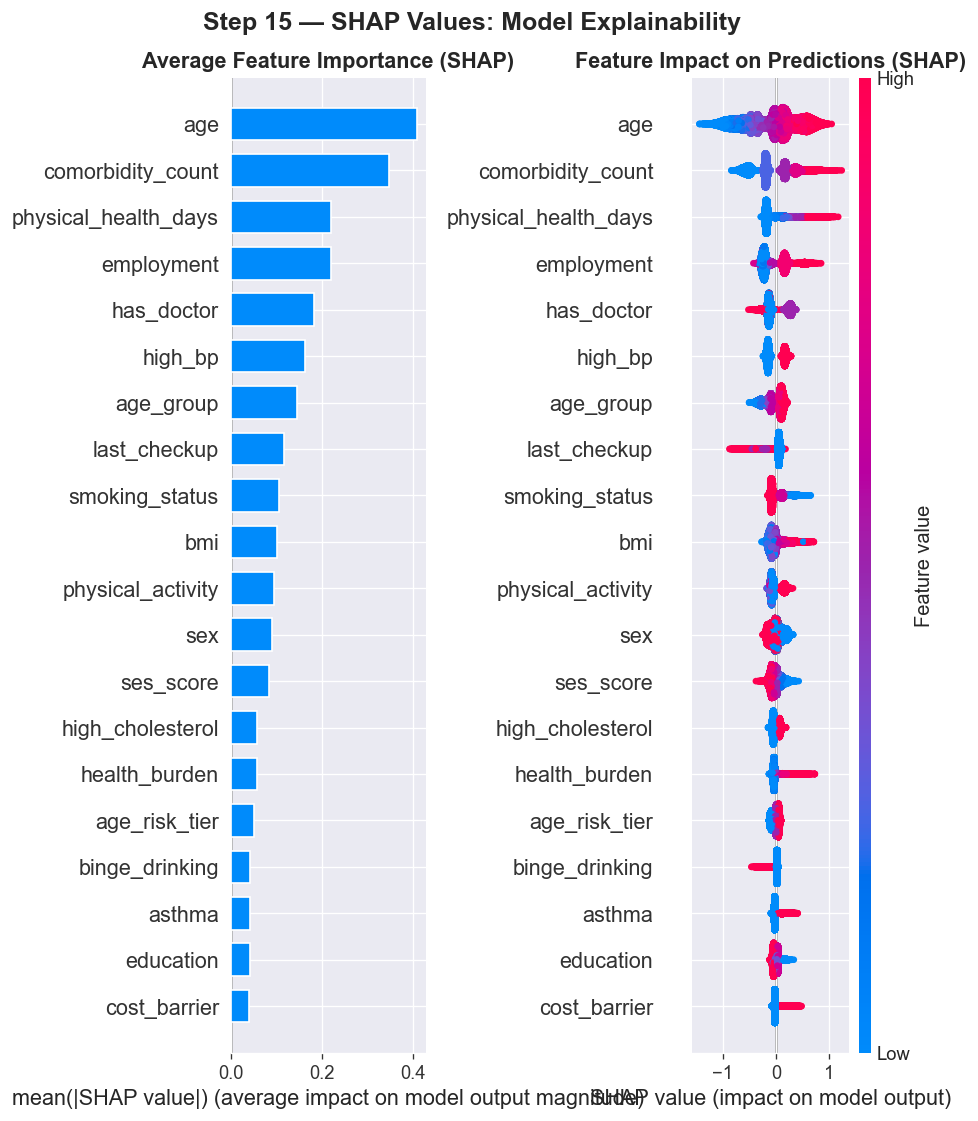

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Step 15 — SHAP Values: Model Explainability',
             fontsize=15, fontweight='bold')

plt.subplot(1, 2, 1)
shap.summary_plot(
    shap_values,
    X_test,
    plot_type = 'bar',
    show      = False
)
plt.title('Average Feature Importance (SHAP)')

plt.subplot(1, 2, 2)
shap.summary_plot(
    shap_values,
    X_test-----,
    show = False
)
plt.title('Feature Impact on Predictions (SHAP)')

plt.tight_layout()
plt.show()

## Step 15 Inference — SHAP Values

The SHAP plots confirm exactly what drives HIGH RISK predictions
in our Tuned XGBoost model.

The top 5 most important features are:

age — the single most powerful predictor by a large margin.
High age values (red dots) push strongly toward HIGH RISK.
Low age values (blue dots) push strongly toward LOW RISK.
This matches everything we saw in EDA — age is the dominant factor.

comorbidity_count — second most important.
Higher number of conditions like high BP, arthritis, depression
push the model toward HIGH RISK. This is clinically expected.

physical_health_days — more bad physical health days means
higher predicted risk. Red dots on the right confirm this.

employment — unemployed or unable to work patients are pushed
toward HIGH RISK. This captures socioeconomic vulnerability
that income alone does not fully explain.

has_doctor — patients without a regular doctor are pushed toward
HIGH RISK. This reflects lack of access to preventive care.

The right side beeswarm plot tells us the direction of each feature.
Red means high feature value. Blue means low feature value.
Dots on the right side mean that feature pushed toward HIGH RISK.
Dots on the left side mean that feature pushed toward LOW RISK.

One important finding — last_checkup has red dots on the left.
This means patients with recent checkups are pushed toward LOW RISK.
Regular healthcare contact is genuinely protective in this model.

The engineered features we created in Step 5 all appear in the list.
comorbidity_count, health_burden, ses_score and age_risk_tier
are all contributing — confirming that feature engineering added
real predictive value to the model.

--------------------------------

## Step 16 — Conclusion

### What we built

A binary classification model to identify HIGH RISK individuals
from the CDC BRFSS 2023 survey of 433,000 Americans using only
self reported health and behavioral data — no blood tests,
no lab values, no mortality records required.

---

### What we found

The best model is Tuned XGBoost with ROC-AUC of 0.8256 and
Recall of 0.7691 at the default threshold of 0.50.

At threshold 0.40 Recall improves to 0.8512 — meaning the model
catches 85 out of every 100 HIGH RISK patients. This is our
recommended operating threshold for real world deployment.

---

### Model Journey

| Step | Model          | ROC-AUC | Recall |
|------|----------------|---------|--------|
| 7    | Logistic Reg   | 0.8170  | 0.5860 |
| 8    | Random Forest  | 0.8195  | 0.5898 |
| 9    | XGBoost        | 0.8244  | 0.7668 |
| 10   | XGBoost Tuned  | 0.8256  | 0.7691 |
| 11   | Neural Network | 0.8144  | 0.7602 |
| 12   | LightGBM       | 0.8253  | 0.7683 |

---

### Key Findings from SHAP

The three most important predictors of mortality risk are
age, comorbidity count and physical health days. These align
perfectly with established clinical knowledge confirming that
the model learned real patterns and not noise.

Patients without a regular doctor and those who skipped recent
checkups were consistently flagged higher risk — showing that
lack of healthcare access is itself a mortality risk factor.

---

### Limitations

BRFSS surveys living people only. There is no actual death outcome
in the data. Our high_risk label is engineered from chronic conditions
which is a proxy for mortality risk, not a direct measure.

The model cannot generalise beyond the US population and the
specific conditions used to define high_risk. It should be
validated on an independent dataset before any clinical use.

---

### Recommendation

Deploy Tuned XGBoost at threshold 0.40 as a screening tool
to help healthcare workers prioritise outreach to the patients
most likely to benefit from early intervention.

This model does not replace clinical judgement. It augments it
by flagging who needs attention first from a pool of hundreds
of thousands of patients that no team could manually review.

----------------------------------

In [ ]:
import joblib
import os

path = os.path.join(os.getcwd(), 'model.pkl')
joblib.dump(xgb_tuned, path)

if os.path.exists(path):
    print("SUCCESS — model saved at:", path)
else:
    print("FAILED — model not saved")

SUCCESS — model saved at /Users/omnaik/Desktop/PROJECTS/CDC_Mortality_Risk/app/model.pkl
